# FOR PAPER

## m2/m1

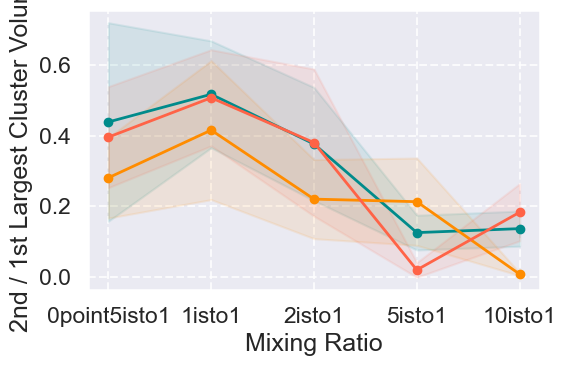

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/extended data s analysis/concat of concats_06102025.csv')

# Extract mixing ratio
df['mixing_ratio'] = df['image'].str.extract(r'_(\d+(?:point\d+)?isto\d+)')

# Helper to convert "10isto1" to numeric 10.0, etc.
def ratio_key(ratio_str):
    return float(ratio_str.replace('point', '.').split('isto')[0]) if isinstance(ratio_str, str) else np.nan

# Compute m2/m1 ratio
def second_to_first_ratio(group):
    sorted_volumes = group['total_volume'].sort_values(ascending=False).values
    largest = sorted_volumes[0]
    second_largest = sorted_volumes[1] if len(sorted_volumes) > 1 else 0.0
    return second_largest / largest if largest > 0 else 0.0

# Compute and merge
ratios_df = df.groupby('image').apply(second_to_first_ratio).reset_index(name='second_to_first_ratio')
ratios_df = ratios_df.merge(df[['image', 'mixing_ratio', 'green_channel_ch2_total_volume']].drop_duplicates(), on='image')

# Seaborn styling
sns.set(style="darkgrid", context="talk")

# Plotting function
def bin_and_plot_with_sem(data, bin_definitions):
    # Bin setup
    bin_edges = [b[0] for b in bin_definitions] + [bin_definitions[-1][1]]
    bin_labels = [f'{start:,}-{end:,}' for start, end in bin_definitions]
    data['volume_bin'] = pd.cut(data['green_channel_ch2_total_volume'], bins=bin_edges, labels=bin_labels, include_lowest=True)

    # Add numeric key for sorting only
    data['numeric_key'] = data['mixing_ratio'].map(ratio_key)

    plt.figure(figsize=(6, 4))
    custom_colors = ['darkcyan', 'darkorange', 'tomato']

    for (label, bin_data), color in zip(data.groupby('volume_bin', observed=True), custom_colors):
        summary = bin_data.groupby('mixing_ratio')['second_to_first_ratio'].agg(['mean', 'sem']).reset_index()
        summary['numeric_key'] = summary['mixing_ratio'].map(ratio_key)
        summary = summary.sort_values('numeric_key', ascending=True)

        x = summary['mixing_ratio'].values
        y = summary['mean'].values
        yerr = summary['sem'].values

        plt.plot(x, y, marker='o', linestyle='-', linewidth=2, markersize=6, color=color)
        plt.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.1)

    # Labels without font control
    plt.xlabel("Mixing Ratio")
    plt.ylabel("2nd / 1st Largest Cluster Volume")

    # Remove legend
    # plt.legend(...)

    plt.grid(True, which='major', linestyle='--', alpha=0.8)
    plt.tight_layout()
    plt.savefig("second_to_first_ratio_plot.png", dpi=300)
    # plt.savefig("second_to_first_ratio_plot.svg")
    plt.show()

# Run the plot
custom_bins = [
    (0, 10000),
    (10001, 20000),
    (20001, np.inf),
]

bin_and_plot_with_sem(ratios_df, bin_definitions=custom_bins)

In [10]:
"""Origial code"""

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Load data

# df = pd.read_csv('/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/extended data s analysis/concat of concats_06102025.csv')

# # Extract mixing ratio
# df['mixing_ratio'] = df['image'].str.extract(r'_(\d+(?:point\d+)?isto\d+)')

# # Helper to convert "10isto1" to numeric 10.0, etc.
# def ratio_key(ratio_str):
#     return float(ratio_str.replace('point', '.').split('isto')[0]) if isinstance(ratio_str, str) else np.nan

# # Compute m2/m1 ratio
# def second_to_first_ratio(group):
#     sorted_volumes = group['total_volume'].sort_values(ascending=False).values
#     largest = sorted_volumes[0]
#     second_largest = sorted_volumes[1] if len(sorted_volumes) > 1 else 0.0
#     return second_largest / largest if largest > 0 else 0.0

# # Compute and merge
# ratios_df = df.groupby('image').apply(second_to_first_ratio).reset_index(name='second_to_first_ratio')
# ratios_df = ratios_df.merge(df[['image', 'mixing_ratio', 'green_channel_ch2_total_volume']].drop_duplicates(), on='image')

# # Seaborn styling
# sns.set(style="darkgrid", context="talk")

# # Beautified plotting function
# def bin_and_plot_with_sem(data, bin_definitions):
#     # Bin setup
#     bin_edges = [b[0] for b in bin_definitions] + [bin_definitions[-1][1]]
#     bin_labels = [f'{start:,}-{end:,}' for start, end in bin_definitions]
#     data['volume_bin'] = pd.cut(data['green_channel_ch2_total_volume'], bins=bin_edges, labels=bin_labels, include_lowest=True)

#     # Add numeric key for sorting only
#     data['numeric_key'] = data['mixing_ratio'].map(ratio_key)

#     plt.figure(figsize=(10, 7))
#     custom_colors = ['darkcyan', 'darkorange', 'tomato']

#     for (label, bin_data), color in zip(data.groupby('volume_bin', observed=True), custom_colors):
#         summary = bin_data.groupby('mixing_ratio')['second_to_first_ratio'].agg(['mean', 'sem']).reset_index()
#         summary['numeric_key'] = summary['mixing_ratio'].map(ratio_key)
#         summary = summary.sort_values('numeric_key', ascending=False)

#         x = summary['mixing_ratio'].values  # categorical, preserves original spacing
#         y = summary['mean'].values
#         yerr = summary['sem'].values

#         plt.plot(x, y, marker='o', linestyle='-', linewidth=2, markersize=6, color=color, label=f'{label} µm³')
#         plt.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.1)

#     # X-axis: use categorical labels
#     plt.xticks(rotation=45, fontsize=12)
#     plt.yticks(fontsize=12)
#     plt.xlabel("Mixing Ratio", fontsize=14)
#     plt.ylabel("2nd / 1st Largest Cluster Volume", fontsize=14)
#     # plt.title("Cluster Size Ratio by Mixing Ratio and Aggregate Size Bin", fontsize=16)
#     plt.grid(True, which='major', linestyle='--', alpha=0.8)
#     plt.legend(title="Aggregate size bin (µm³)", title_fontsize=14, fontsize=13, frameon=False)
#     plt.tight_layout()
#     plt.savefig("second_to_first_ratio_plot.png", dpi=300)
#     plt.savefig("second_to_first_ratio_plot.svg")
#     plt.show()

# # Run the plot with your bin definition
# custom_bins = [
#     (0, 10000),
#     (10001, 20000),
#     (20001, np.inf),
# ]

# bin_and_plot_with_sem(ratios_df, bin_definitions=custom_bins)

'Origial code'

## radius of gyration

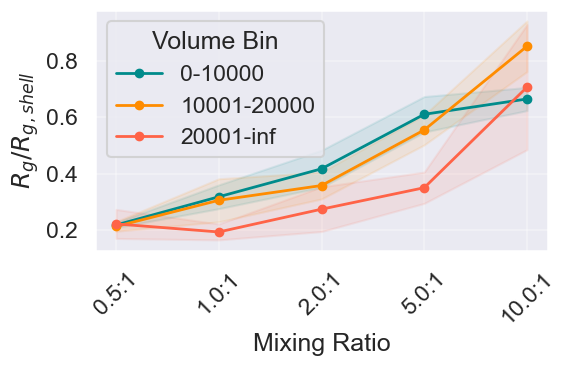

In [30]:
# computation does not take place in this snippet
#use the path of the csv to locate code and other raw csv files for this 


import pandas as pd
import matplotlib.pyplot as plt

# === Input ===
SUMMARY_PATH = '/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/extended data s analysis/radius of gyration analysis/Summary_normalised_R1.csv'  # <-- change to your actual path
CUSTOM_BINS = [
    (0, 10000),
    (10001, 20000),
    (20001, float("inf"))
]
custom_colors = ['darkcyan', 'darkorange', 'tomato']

# Load summary
summary = pd.read_csv(SUMMARY_PATH)

# Decide which error column to use
if "sem_normalized_rg" in summary.columns:
    err_col = "sem_normalized_rg"
elif "std_normalized_rg" in summary.columns:
    err_col = "std_normalized_rg"
else:
    raise ValueError("Expected either sem_normalized_rg or std_normalized_rg in the CSV.")

# Make categorical x labels (string form)
summary['mixing_label'] = summary['mixing_ratio'].apply(lambda r: f"{r:.1f}:1")

# Define desired order (so categories are evenly spaced)
order = [f"{r:.1f}:1" for r in sorted(summary['mixing_ratio'].unique())]
summary['mixing_label'] = pd.Categorical(summary['mixing_label'], categories=order, ordered=True)

# === Plot ===
plt.figure(figsize=(6, 4))

for i, (bin_min, bin_max) in enumerate(CUSTOM_BINS):
    label = f"{bin_min}-{int(bin_max) if bin_max != float('inf') else 'inf'}"
    bin_data = summary[summary['volume_bin'] == label].copy()

    if bin_data.empty:
        continue

    # Use category codes for x positions
    x = bin_data['mixing_label'].cat.codes
    xticks = bin_data['mixing_label'].values
    y = bin_data['avg_normalized_rg'].values
    yerr = bin_data[err_col].values

    plt.plot(
        x, y, marker='o', linestyle='-', linewidth=2, markersize=6,
        color=custom_colors[i], label=label
    )
    plt.fill_between(x, y - yerr, y + yerr, color=custom_colors[i], alpha=0.1)

# Replace tick codes with labels
plt.xticks(range(len(order)), order, rotation=45)

plt.xlabel("Mixing Ratio")
plt.ylabel(r"$R_g / R_{g, shell}$")
# plt.legend(title="Volume Bin")
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig("normalized_rg_plot_categorical.svg")
# plt.savefig("normalized_rg_plot_categorical.png", dpi=300)
plt.show()

# new new analysis

In [28]:
# the concatanation code is at the end of this file

In [1]:
#csv from custom density and binary clustering

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/extended data s analysis/concat of concats_06102025.csv') 

In [3]:

# Extract mixing ratio from the 'image' column
df['mixing_ratio'] = df['image'].str.extract(r'_(\d+(?:point\d+)?isto\d+)')

In [4]:
date="061025" #adding date in the filename
df.to_csv(f"ratiosextracted_{date}.csv")

In [5]:
import pandas as pd

# Read your CSV
df = pd.read_csv('concat of concats_06102025.csv')

# Ensure the mixing ratio column exists/extracted
df['mixing_ratio'] = df['image'].str.extract(r'_(\d+(?:point\d+)?isto\d+)')

# Define bins for green_channel_ch2_total_volume (edit as needed)
bin_edges = [0, 10000, 20000, 2000000]
bin_labels = ['0-10000', '10001-20000', '20001 and over']
df['green_volume_bin'] = pd.cut(df['green_channel_ch2_total_volume'], bins=bin_edges, labels=bin_labels, include_lowest=True)

# Count unique images per (ratio, bin)
pivot = (
    df.groupby(['mixing_ratio', 'green_volume_bin'])['image']
    .nunique()
    .unstack(fill_value=0)
)

print(pivot)

green_volume_bin  0-10000  10001-20000  20001 and over
mixing_ratio                                          
0point5isto1            3           10               6
10isto1                25            8               2
1isto1                  5            4               6
2isto1                  8            4               3
5isto1                 13            4               2


/var/folders/0d/bvrgm3_11sn91zj4_tx79tl80000gq/T/ipykernel_1731/3355122203.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['mixing_ratio', 'green_volume_bin'])['image']


In [6]:
""" DO NOT RUN THIS CELL """
 
 """ older bins"""

IndentationError: unexpected indent (1129705866.py, line 3)

/var/folders/0d/bvrgm3_11sn91zj4_tx79tl80000gq/T/ipykernel_2077/1942129275.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for label, bin_data in data.groupby('volume_bin'):


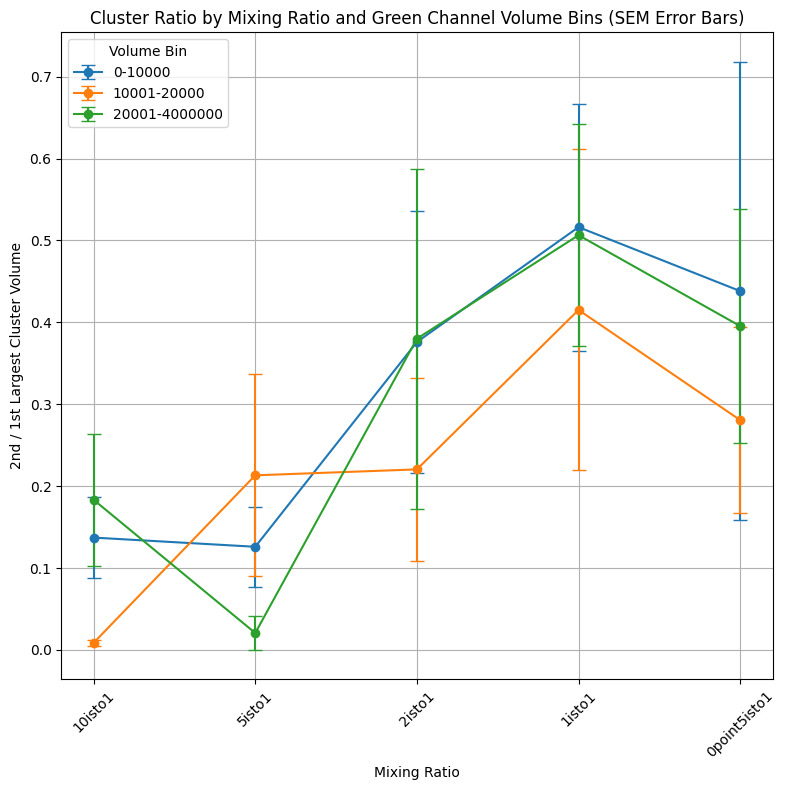

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/extended data s analysis/concat of concats_06102025.csv') 
# Extract mixing ratio
df['mixing_ratio'] = df['image'].str.extract(r'_(\d+(?:point\d+)?isto\d+)')

# Helper to convert "10isto1" to numeric 10.0, etc.
def ratio_key(ratio_str):
    return float(ratio_str.replace('point', '.').split('isto')[0])

# Compute m2/m1 ratios per image
def second_to_first_ratio(group):
    sorted_volumes = group['total_volume'].sort_values(ascending=False).values
    largest = sorted_volumes[0]
    second_largest = sorted_volumes[1] if len(sorted_volumes) > 1 else 0.0
    return second_largest / largest if largest > 0 else 0.0

ratios_df = df.groupby('image').apply(second_to_first_ratio).reset_index(name='second_to_first_ratio')
ratios_df = ratios_df.merge(df[['image', 'mixing_ratio', 'green_channel_ch2_total_volume']].drop_duplicates(), on='image')

# Flexible binning function with SEM error bars
def bin_and_plot_with_sem(data, bin_definitions):
    # Create bins and labels based on explicit definitions
    bin_edges = [b[0] for b in bin_definitions] + [bin_definitions[-1][1]]
    bin_labels = [f'{start}-{end}' for start, end in bin_definitions]
    data['volume_bin'] = pd.cut(data['green_channel_ch2_total_volume'], bins=bin_edges, labels=bin_labels, include_lowest=True)

    # Sort mixing_ratio for x-axis ordering
    data['numeric_key'] = data['mixing_ratio'].map(ratio_key)
    data = data.sort_values(by='numeric_key', ascending=False)

    # Prepare plot
    plt.figure(figsize=(8, 8))

    # Process and plot each bin
    for label, bin_data in data.groupby('volume_bin'):
        summary = bin_data.groupby('mixing_ratio')['second_to_first_ratio'].agg(['mean', 'sem']).reset_index()
        summary['numeric_key'] = summary['mixing_ratio'].map(ratio_key)
        summary = summary.sort_values(by='numeric_key', ascending=False)

        plt.errorbar(
            summary['mixing_ratio'],
            summary['mean'],
            yerr=summary['sem'],
            fmt='-o',
            label=label,
            capsize=5
        )

    plt.xticks(rotation=45)
    plt.title('Cluster Ratio by Mixing Ratio and Green Channel Volume Bins (SEM Error Bars)')
    plt.xlabel('Mixing Ratio')
    plt.ylabel('2nd / 1st Largest Cluster Volume')
    plt.grid(True)
    plt.tight_layout()
    plt.legend(title='Volume Bin')
    plt.show()

# Example bin definition and usage
custom_bins = [
    (0, 10000),
    (10001, 20000),
    (20001, 4000000),
]

bin_and_plot_with_sem(ratios_df, bin_definitions=custom_bins)

In [ ]:
# Beautifying the above plot

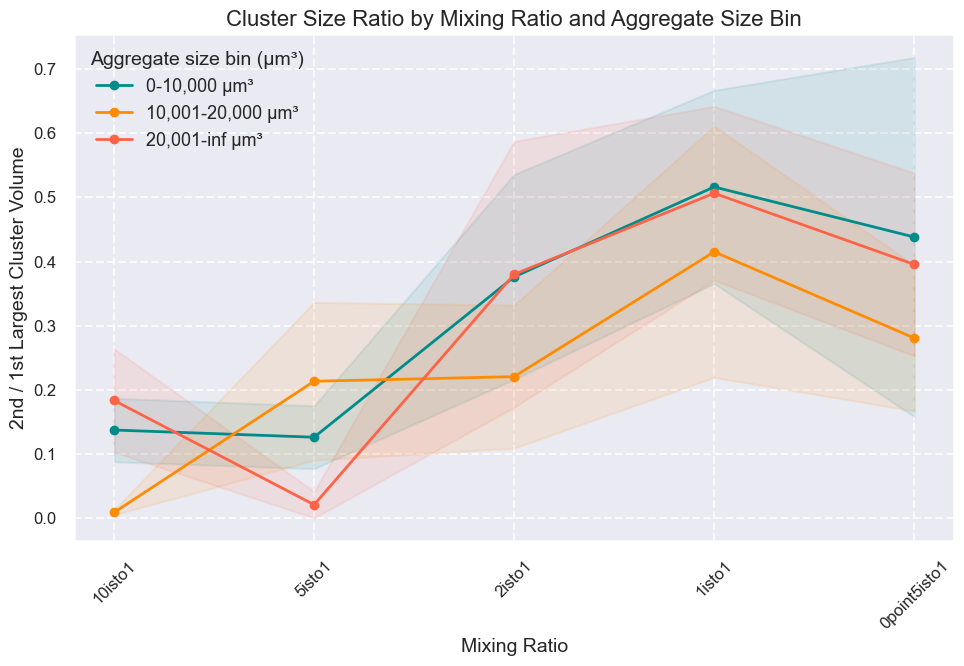

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/extended data s analysis/concat of concats_06102025.csv')
df = pd.read_csv('/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/extended data s analysis/concat of concats_06102025.csv')

# Extract mixing ratio
df['mixing_ratio'] = df['image'].str.extract(r'_(\d+(?:point\d+)?isto\d+)')

# Helper to convert "10isto1" to numeric 10.0, etc.
def ratio_key(ratio_str):
    return float(ratio_str.replace('point', '.').split('isto')[0]) if isinstance(ratio_str, str) else np.nan

# Compute m2/m1 ratio
def second_to_first_ratio(group):
    sorted_volumes = group['total_volume'].sort_values(ascending=False).values
    largest = sorted_volumes[0]
    second_largest = sorted_volumes[1] if len(sorted_volumes) > 1 else 0.0
    return second_largest / largest if largest > 0 else 0.0

# Compute and merge
ratios_df = df.groupby('image').apply(second_to_first_ratio).reset_index(name='second_to_first_ratio')
ratios_df = ratios_df.merge(df[['image', 'mixing_ratio', 'green_channel_ch2_total_volume']].drop_duplicates(), on='image')

# Seaborn styling
sns.set(style="darkgrid", context="talk")

# Beautified plotting function
def bin_and_plot_with_sem(data, bin_definitions):
    # Bin setup
    bin_edges = [b[0] for b in bin_definitions] + [bin_definitions[-1][1]]
    bin_labels = [f'{start:,}-{end:,}' for start, end in bin_definitions]
    data['volume_bin'] = pd.cut(data['green_channel_ch2_total_volume'], bins=bin_edges, labels=bin_labels, include_lowest=True)

    # Add numeric key for sorting only
    data['numeric_key'] = data['mixing_ratio'].map(ratio_key)

    plt.figure(figsize=(10, 7))
    custom_colors = ['darkcyan', 'darkorange', 'tomato']

    for (label, bin_data), color in zip(data.groupby('volume_bin', observed=True), custom_colors):
        summary = bin_data.groupby('mixing_ratio')['second_to_first_ratio'].agg(['mean', 'sem']).reset_index()
        summary['numeric_key'] = summary['mixing_ratio'].map(ratio_key)
        summary = summary.sort_values('numeric_key', ascending=False)

        x = summary['mixing_ratio'].values  # categorical, preserves original spacing
        y = summary['mean'].values
        yerr = summary['sem'].values

        plt.plot(x, y, marker='o', linestyle='-', linewidth=2, markersize=6, color=color, label=f'{label} µm³')
        plt.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.1)

    # X-axis: use categorical labels
    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlabel("Mixing Ratio", fontsize=14)
    plt.ylabel("2nd / 1st Largest Cluster Volume", fontsize=14)
    plt.title("Cluster Size Ratio by Mixing Ratio and Aggregate Size Bin", fontsize=16)
    plt.grid(True, which='major', linestyle='--', alpha=0.8)
    plt.legend(title="Aggregate size bin (µm³)", title_fontsize=14, fontsize=13, frameon=False)
    plt.tight_layout()
    plt.savefig("second_to_first_ratio_plot.png", dpi=300)
    plt.show()

# Run the plot with your bin definition
custom_bins = [
    (0, 10000),
    (10001, 20000),
    (20001, np.inf),
]

bin_and_plot_with_sem(ratios_df, bin_definitions=custom_bins)

/var/folders/0d/bvrgm3_11sn91zj4_tx79tl80000gq/T/ipykernel_2077/1478107257.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for label, bin_data in data.groupby('volume_bin'):


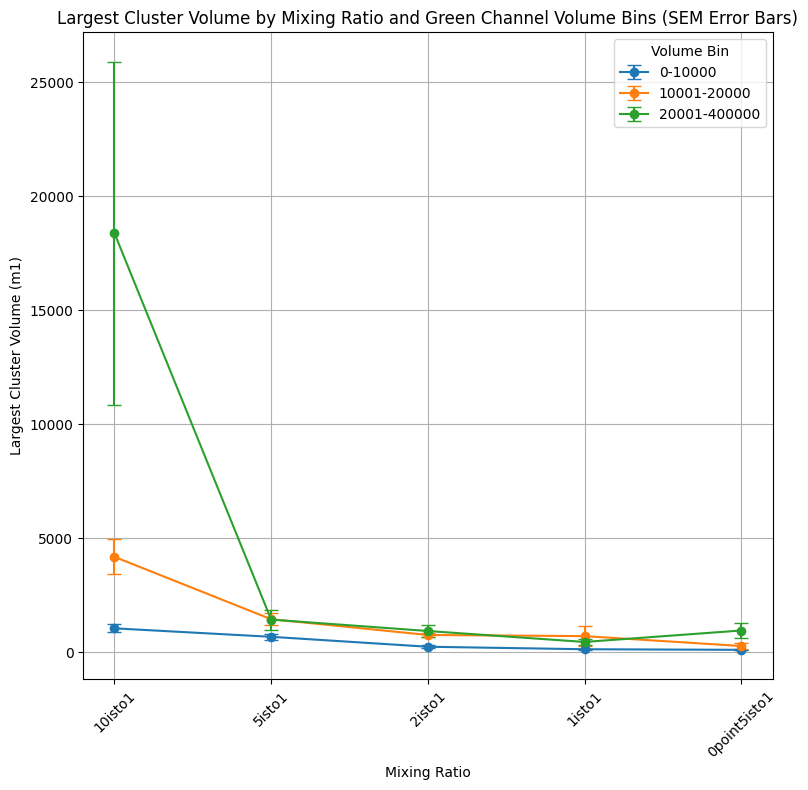

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/extended data s analysis/concat of concats_06102025.csv') 

# Extract mixing ratio
df['mixing_ratio'] = df['image'].str.extract(r'_(\d+(?:point\d+)?isto\d+)')

# Helper to convert "10isto1" to numeric 10.0, etc.
def ratio_key(ratio_str):
    return float(ratio_str.replace('point', '.').split('isto')[0])

# Compute largest cluster volume (m1) per image
def largest_cluster_volume(group):
    sorted_volumes = group['total_volume'].sort_values(ascending=False).values
    largest = sorted_volumes[0]
    return largest

largest_df = df.groupby('image').apply(largest_cluster_volume).reset_index(name='largest_cluster_volume')
largest_df = largest_df.merge(df[['image', 'mixing_ratio', 'green_channel_ch2_total_volume']].drop_duplicates(), on='image')

# Flexible binning function with SEM error bars for m1
def bin_and_plot_largest_with_sem(data, bin_definitions):
    # Create bins and labels based on explicit definitions
    bin_edges = [b[0] for b in bin_definitions] + [bin_definitions[-1][1]]
    bin_labels = [f'{start}-{end}' for start, end in bin_definitions]
    data['volume_bin'] = pd.cut(data['green_channel_ch2_total_volume'], bins=bin_edges, labels=bin_labels, include_lowest=True)

    # Sort mixing_ratio for x-axis ordering
    data['numeric_key'] = data['mixing_ratio'].map(ratio_key)
    data = data.sort_values(by='numeric_key', ascending=False)

    # Prepare plot
    plt.figure(figsize=(8, 8))

    # Process and plot each bin
    for label, bin_data in data.groupby('volume_bin'):
        summary = bin_data.groupby('mixing_ratio')['largest_cluster_volume'].agg(['mean', 'sem']).reset_index()
        summary['numeric_key'] = summary['mixing_ratio'].map(ratio_key)
        summary = summary.sort_values(by='numeric_key', ascending=False)

        plt.errorbar(
            summary['mixing_ratio'],
            summary['mean'],
            yerr=summary['sem'],
            fmt='-o',
            label=label,
            capsize=5
        )

    plt.xticks(rotation=45)
    plt.title('Largest Cluster Volume by Mixing Ratio and Green Channel Volume Bins (SEM Error Bars)')
    plt.xlabel('Mixing Ratio')
    plt.ylabel('Largest Cluster Volume (m1)')
    plt.grid(True)
    plt.tight_layout()
    plt.legend(title='Volume Bin')
    plt.show()

# Example bin definition and usage
custom_bins = [
    (0, 10000),
    (10001, 20000),
    (20001, 400000),
]

bin_and_plot_largest_with_sem(largest_df, bin_definitions=custom_bins)

/var/folders/0d/bvrgm3_11sn91zj4_tx79tl80000gq/T/ipykernel_2077/1439630835.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for label, bin_data in data.groupby('volume_bin'):


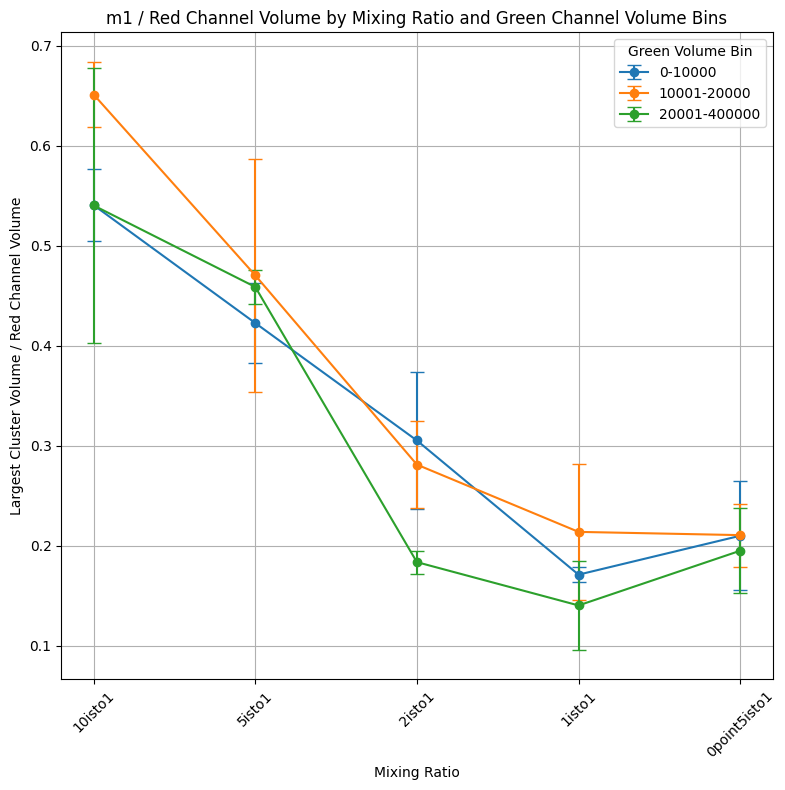

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/extended data s analysis/concat of concats_06102025.csv') 

# Extract mixing ratio
df['mixing_ratio'] = df['image'].str.extract(r'_(\d+(?:point\d+)?isto\d+)')

# Helper to convert "10isto1" to numeric 10.0, etc.
def ratio_key(ratio_str):
    return float(ratio_str.replace('point', '.').split('isto')[0])

# Compute m1 / red_channel ratio per image
def m1_red_ratio(group):
    sorted_volumes = group['total_volume'].sort_values(ascending=False).values
    m1 = sorted_volumes[0]
    red_volume = group['red_channel_ch1_total_volume'].iloc[0]
    ratio = m1 / red_volume if red_volume > 0 else np.nan
    return ratio

# Apply function and merge needed info
ratio_df = df.groupby('image').apply(m1_red_ratio).reset_index(name='m1_to_red_ratio')
ratio_df = ratio_df.merge(df[['image', 'mixing_ratio', 'green_channel_ch2_total_volume']].drop_duplicates(), on='image')

# Flexible binning and SEM error plotting function
def bin_and_plot_m1_red_ratio(data, bin_definitions):
    # Bin green channel volume
    bin_edges = [b[0] for b in bin_definitions] + [bin_definitions[-1][1]]
    bin_labels = [f'{start}-{end}' for start, end in bin_definitions]
    data['volume_bin'] = pd.cut(data['green_channel_ch2_total_volume'], bins=bin_edges, labels=bin_labels, include_lowest=True)

    # Sort x-axis order
    data['numeric_key'] = data['mixing_ratio'].map(ratio_key)
    data = data.sort_values(by='numeric_key', ascending=False)

    # Plot
    plt.figure(figsize=(8, 8))

    for label, bin_data in data.groupby('volume_bin'):
        summary = bin_data.groupby('mixing_ratio')['m1_to_red_ratio'].agg(['mean', 'sem']).reset_index()
        summary['numeric_key'] = summary['mixing_ratio'].map(ratio_key)
        summary = summary.sort_values(by='numeric_key', ascending=False)

        plt.errorbar(
            summary['mixing_ratio'],
            summary['mean'],
            yerr=summary['sem'],
            fmt='-o',
            label=label,
            capsize=5
        )

    plt.xticks(rotation=45)
    plt.title('m1 / Red Channel Volume by Mixing Ratio and Green Channel Volume Bins')
    plt.xlabel('Mixing Ratio')
    plt.ylabel('Largest Cluster Volume / Red Channel Volume')
    plt.grid(True)
    plt.tight_layout()
    plt.legend(title='Green Volume Bin')
    plt.show()

# Define and run
custom_bins = [
    (0, 10000),
    (10001, 20000),
    (20001, 400000),
]

bin_and_plot_m1_red_ratio(ratio_df, bin_definitions=custom_bins)

In [1]:
#beautifying above plot

/var/folders/0d/bvrgm3_11sn91zj4_tx79tl80000gq/T/ipykernel_3675/1725831375.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (label, bin_data), color in zip(data.groupby('volume_bin'), custom_colors):


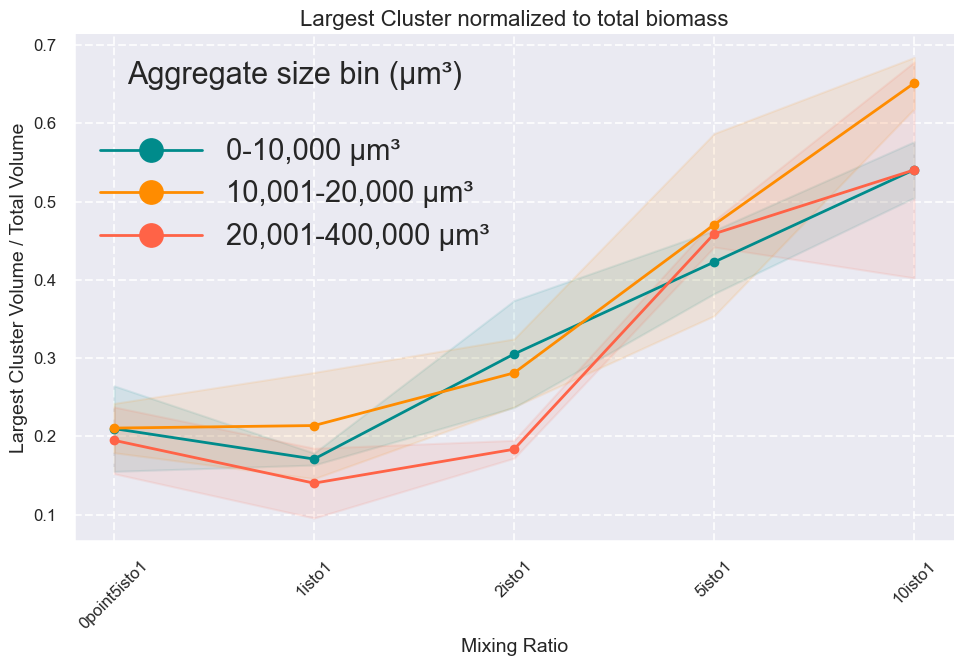

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/extended data s analysis/concat of concats_06102025.csv')

# Extract mixing ratio
df['mixing_ratio'] = df['image'].str.extract(r'_(\d+(?:point\d+)?isto\d+)')

# Helper to convert "10isto1" to numeric 10.0, etc.
def ratio_key(ratio_str):
    return float(ratio_str.replace('point', '.').split('isto')[0]) if isinstance(ratio_str, str) else np.nan

# Compute m1 / red_channel ratio per image
def m1_red_ratio(group):
    sorted_volumes = group['total_volume'].sort_values(ascending=False).values
    m1 = sorted_volumes[0]
    red_volume = group['red_channel_ch1_total_volume'].iloc[0]
    ratio = m1 / red_volume if red_volume > 0 else np.nan
    return ratio

# Apply function and merge needed info
ratio_df = df.groupby('image').apply(m1_red_ratio).reset_index(name='m1_to_red_ratio')
ratio_df = ratio_df.merge(df[['image', 'mixing_ratio', 'green_channel_ch2_total_volume']].drop_duplicates(), on='image')

# Seaborn styling
sns.set(style="darkgrid", context="talk")

# Plotting function with shaded SEM
def bin_and_plot_m1_red_ratio(data, bin_definitions):
    # Bin green channel volume
    bin_edges = [b[0] for b in bin_definitions] + [bin_definitions[-1][1]]
    bin_labels = [f'{start:,}-{end:,}' for start, end in bin_definitions]
    data['volume_bin'] = pd.cut(data['green_channel_ch2_total_volume'], bins=bin_edges, labels=bin_labels, include_lowest=True)

    # Sort x-axis order
    data['numeric_key'] = data['mixing_ratio'].map(ratio_key)
    data = data.sort_values(by='numeric_key', ascending=False)

    # Set up figure
    plt.figure(figsize=(10, 7))

    # Custom colors: cadetblue, gold, tomato
    custom_colors = ['darkcyan', 'darkorange', 'tomato'] #######################

    for (label, bin_data), color in zip(data.groupby('volume_bin'), custom_colors):
        summary = bin_data.groupby('mixing_ratio')['m1_to_red_ratio'].agg(['mean', 'sem']).reset_index()
        summary['numeric_key'] = summary['mixing_ratio'].map(ratio_key)
        summary = summary.sort_values(by='numeric_key', ascending=False)

        # Line plot
        plt.plot(
            summary['mixing_ratio'],
            summary['mean'],
            marker='o',
            linestyle='-',
            linewidth=2,
            markersize=6,
            color=color,
            label=f'{label} µm³'
        )

        # Shaded area for SEM
        plt.fill_between(
            summary['mixing_ratio'],
            summary['mean'] - summary['sem'],
            summary['mean'] + summary['sem'],
            color=color,
            alpha=0.1
        )

    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.title('Largest Cluster normalized to total biomass', fontsize=16)
    plt.xlabel('Mixing Ratio', fontsize=14)
    plt.ylabel('Largest Cluster Volume / Total Volume', fontsize=14)
    plt.grid(True, which='major', linestyle='--', alpha=0.8)
    plt.tight_layout()
    
    plt.legend(
    title='Aggregate size bin (µm³)\n',
    title_fontsize=22,
    fontsize=21,
    frameon=False,
    markerscale=2.8,  # scale up marker size in legend
    handlelength=3.5  # optional: elongate marker lines
    )
    
    plt.gca().invert_xaxis()
    sns.despine()
    plt.savefig("m1bytotalred.png", dpi=300)
    plt.show()

# Define custom volume bins and run the plot
custom_bins = [
    (0, 10000),
    (10001, 20000),
    (20001, 400000),
]

bin_and_plot_m1_red_ratio(ratio_df, bin_definitions=custom_bins)

/var/folders/0d/bvrgm3_11sn91zj4_tx79tl80000gq/T/ipykernel_2077/290394673.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for label, bin_data in data.groupby('volume_bin'):


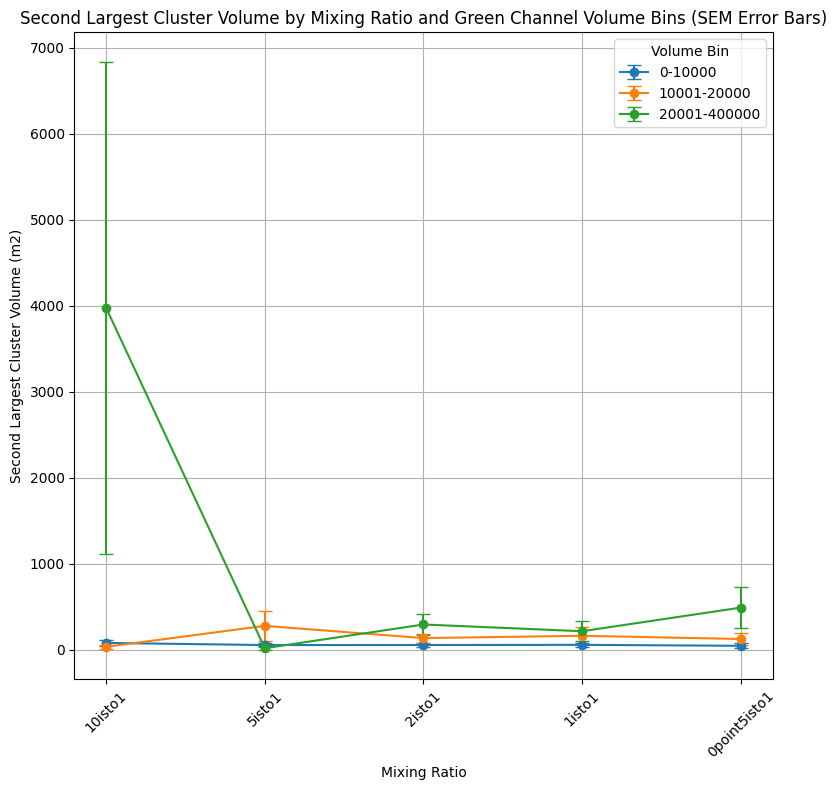

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/extended data s analysis/concat of concats_06102025.csv') 

# Extract mixing ratio
df['mixing_ratio'] = df['image'].str.extract(r'_(\d+(?:point\d+)?isto\d+)')

# Helper to convert "10isto1" to numeric 10.0, etc.
def ratio_key(ratio_str):
    return float(ratio_str.replace('point', '.').split('isto')[0])

# Compute second largest cluster volume (m2) per image
def second_largest_cluster_volume(group):
    sorted_volumes = group['total_volume'].sort_values(ascending=False).values
    second_largest = sorted_volumes[1] if len(sorted_volumes) > 1 else 0.0
    return second_largest

second_largest_df = df.groupby('image').apply(second_largest_cluster_volume).reset_index(name='second_largest_cluster_volume')
second_largest_df = second_largest_df.merge(df[['image', 'mixing_ratio', 'green_channel_ch2_total_volume']].drop_duplicates(), on='image')

# Flexible binning function with SEM error bars for m2
def bin_and_plot_second_largest_with_sem(data, bin_definitions):
    bin_edges = [b[0] for b in bin_definitions] + [bin_definitions[-1][1]]
    bin_labels = [f'{start}-{end}' for start, end in bin_definitions]
    data['volume_bin'] = pd.cut(data['green_channel_ch2_total_volume'], bins=bin_edges, labels=bin_labels, include_lowest=True)

    data['numeric_key'] = data['mixing_ratio'].map(ratio_key)
    data = data.sort_values(by='numeric_key', ascending=False)

    plt.figure(figsize=(8, 8))

    for label, bin_data in data.groupby('volume_bin'):
        summary = bin_data.groupby('mixing_ratio')['second_largest_cluster_volume'].agg(['mean', 'sem']).reset_index()
        summary['numeric_key'] = summary['mixing_ratio'].map(ratio_key)
        summary = summary.sort_values(by='numeric_key', ascending=False)

        plt.errorbar(
            summary['mixing_ratio'],
            summary['mean'],
            yerr=summary['sem'],
            fmt='-o',
            label=label,
            capsize=5
        )

    plt.xticks(rotation=45)
    plt.title('Second Largest Cluster Volume by Mixing Ratio and Green Channel Volume Bins (SEM Error Bars)')
    plt.xlabel('Mixing Ratio')
    plt.ylabel('Second Largest Cluster Volume (m2)')
    plt.grid(True)
    plt.tight_layout()
    plt.legend(title='Volume Bin')
    plt.show()

# Example bin definition and usage
custom_bins = [
    (0, 10000),
    (10001, 20000),
    (20001, 400000),
]

bin_and_plot_second_largest_with_sem(second_largest_df, bin_definitions=custom_bins)

/var/folders/0d/bvrgm3_11sn91zj4_tx79tl80000gq/T/ipykernel_2077/951338477.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for label, bin_data in data.groupby('volume_bin'):


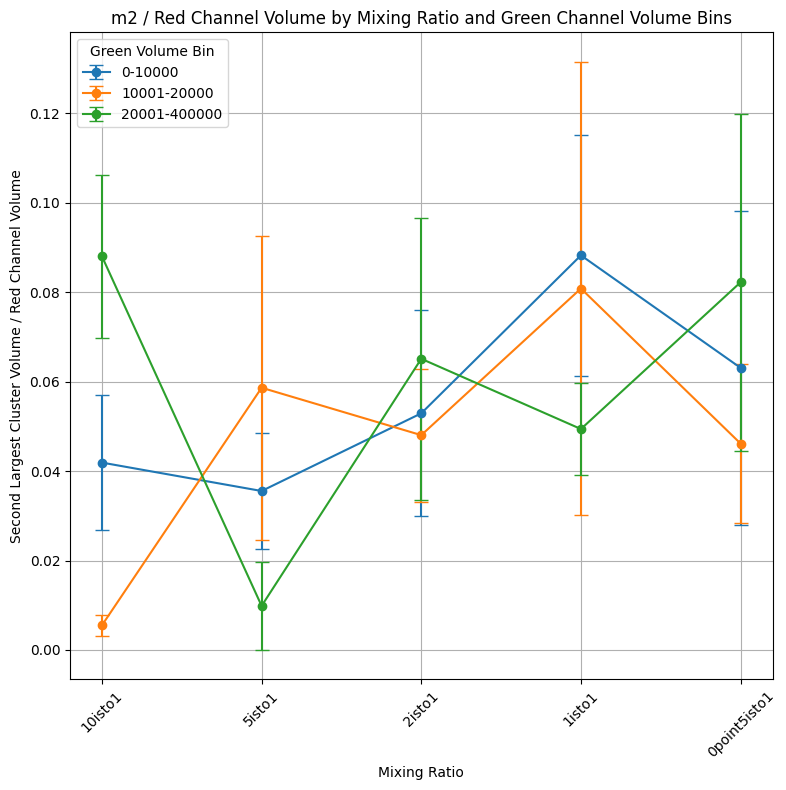

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/extended data s analysis/concat of concats_06102025.csv') 

# Extract mixing ratio
df['mixing_ratio'] = df['image'].str.extract(r'_(\d+(?:point\d+)?isto\d+)')

# Helper to convert "10isto1" to numeric 10.0, etc.
def ratio_key(ratio_str):
    return float(ratio_str.replace('point', '.').split('isto')[0])

# Compute m2 / red_channel ratio per image
def m2_red_ratio(group):
    sorted_volumes = group['total_volume'].sort_values(ascending=False).values
    m2 = sorted_volumes[1] if len(sorted_volumes) > 1 else 0.0
    red_volume = group['red_channel_ch1_total_volume'].iloc[0]
    ratio = m2 / red_volume if red_volume > 0 else np.nan
    return ratio

# Apply function and merge needed info
ratio_df = df.groupby('image').apply(m2_red_ratio).reset_index(name='m2_to_red_ratio')
ratio_df = ratio_df.merge(df[['image', 'mixing_ratio', 'green_channel_ch2_total_volume']].drop_duplicates(), on='image')

# Flexible binning and SEM error plotting function
def bin_and_plot_m2_red_ratio(data, bin_definitions):
    # Bin green channel volume
    bin_edges = [b[0] for b in bin_definitions] + [bin_definitions[-1][1]]
    bin_labels = [f'{start}-{end}' for start, end in bin_definitions]
    data['volume_bin'] = pd.cut(data['green_channel_ch2_total_volume'], bins=bin_edges, labels=bin_labels, include_lowest=True)

    # Sort x-axis order
    data['numeric_key'] = data['mixing_ratio'].map(ratio_key)
    data = data.sort_values(by='numeric_key', ascending=False)

    # Plot
    plt.figure(figsize=(8, 8))

    for label, bin_data in data.groupby('volume_bin'):
        summary = bin_data.groupby('mixing_ratio')['m2_to_red_ratio'].agg(['mean', 'sem']).reset_index()
        summary['numeric_key'] = summary['mixing_ratio'].map(ratio_key)
        summary = summary.sort_values(by='numeric_key', ascending=False)

        plt.errorbar(
            summary['mixing_ratio'],
            summary['mean'],
            yerr=summary['sem'],
            fmt='-o',
            label=label,
            capsize=5
        )

    plt.xticks(rotation=45)
    plt.title('m2 / Red Channel Volume by Mixing Ratio and Green Channel Volume Bins')
    plt.xlabel('Mixing Ratio')
    plt.ylabel('Second Largest Cluster Volume / Red Channel Volume')
    plt.grid(True)
    plt.tight_layout()
    plt.legend(title='Green Volume Bin')
    plt.show()

# Define and run
custom_bins = [
    (0, 10000),
    (10001, 20000),
    (20001, 400000),
]

bin_and_plot_m2_red_ratio(ratio_df, bin_definitions=custom_bins)

/var/folders/0d/bvrgm3_11sn91zj4_tx79tl80000gq/T/ipykernel_2077/2374986041.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for label, bin_data in data.groupby('volume_bin'):


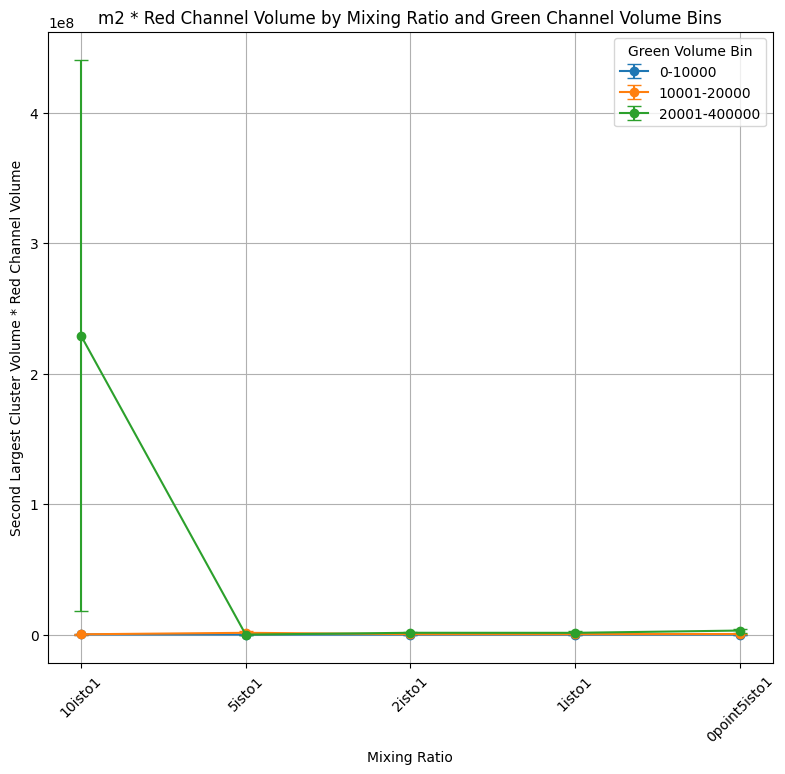

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/extended data s analysis/concat of concats_06102025.csv') 

# Extract mixing ratio
df['mixing_ratio'] = df['image'].str.extract(r'_(\d+(?:point\d+)?isto\d+)')

# Helper to convert "10isto1" to numeric 10.0, etc.
def ratio_key(ratio_str):
    return float(ratio_str.replace('point', '.').split('isto')[0])

# Compute m2 * red_channel volume per image
def m2_times_red_volume(group):
    sorted_volumes = group['total_volume'].sort_values(ascending=False).values
    m2 = sorted_volumes[1] if len(sorted_volumes) > 1 else 0.0
    red_volume = group['red_channel_ch1_total_volume'].iloc[0]
    product = m2 * red_volume
    return product

# Apply function and merge needed info
product_df = df.groupby('image').apply(m2_times_red_volume).reset_index(name='m2_times_red')
product_df = product_df.merge(df[['image', 'mixing_ratio', 'green_channel_ch2_total_volume']].drop_duplicates(), on='image')

# Flexible binning and SEM error plotting function
def bin_and_plot_m2_times_red(data, bin_definitions):
    bin_edges = [b[0] for b in bin_definitions] + [bin_definitions[-1][1]]
    bin_labels = [f'{start}-{end}' for start, end in bin_definitions]
    data['volume_bin'] = pd.cut(data['green_channel_ch2_total_volume'], bins=bin_edges, labels=bin_labels, include_lowest=True)

    data['numeric_key'] = data['mixing_ratio'].map(ratio_key)
    data = data.sort_values(by='numeric_key', ascending=False)

    plt.figure(figsize=(8, 8))

    for label, bin_data in data.groupby('volume_bin'):
        summary = bin_data.groupby('mixing_ratio')['m2_times_red'].agg(['mean', 'sem']).reset_index()
        summary['numeric_key'] = summary['mixing_ratio'].map(ratio_key)
        summary = summary.sort_values(by='numeric_key', ascending=False)

        plt.errorbar(
            summary['mixing_ratio'],
            summary['mean'],
            yerr=summary['sem'],
            fmt='-o',
            label=label,
            capsize=5
        )

    plt.xticks(rotation=45)
    plt.title('m2 * Red Channel Volume by Mixing Ratio and Green Channel Volume Bins')
    plt.xlabel('Mixing Ratio')
    plt.ylabel('Second Largest Cluster Volume * Red Channel Volume')
    plt.grid(True)
    plt.tight_layout()
    plt.legend(title='Green Volume Bin')
    plt.show()

# Define and run
custom_bins = [
    (0, 10000),
    (10001, 20000),
    (20001, 400000),
]

bin_and_plot_m2_times_red(product_df, bin_definitions=custom_bins)

# relative clustering viz

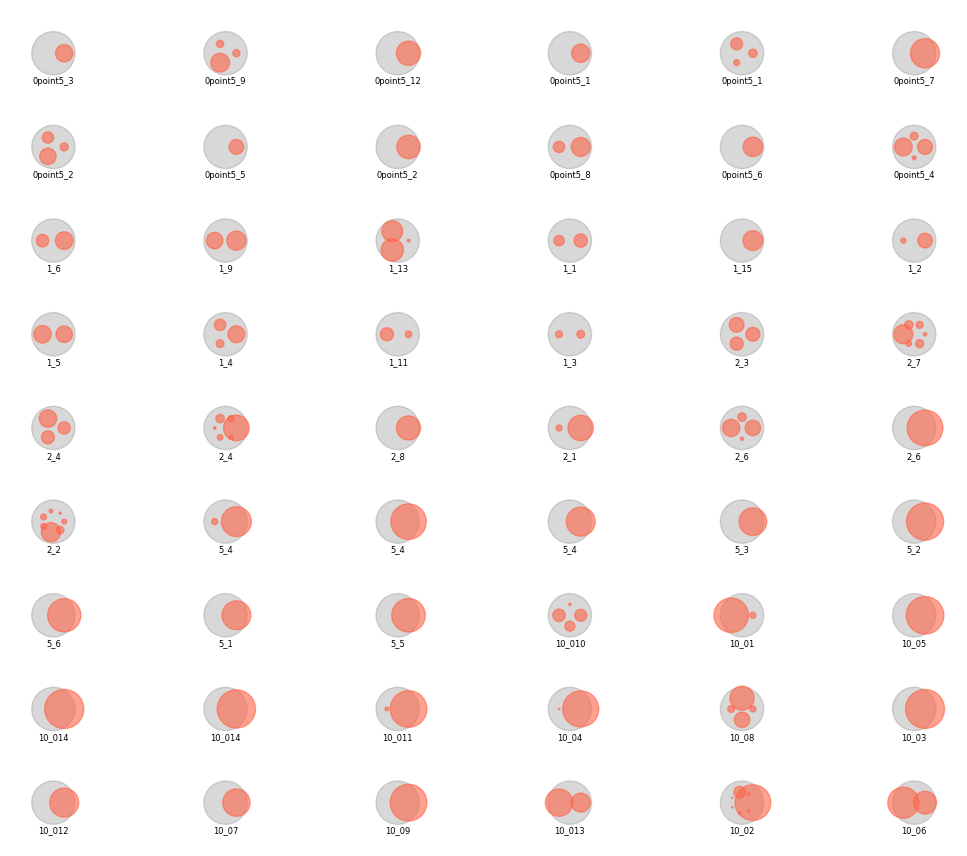

Saved to /Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/custom density with binary clustering/fixed_gray_diameter_area_scaled.pdf


In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re



# Load data
df = pd.read_csv('/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/custom density with binary clustering/concat of concats.csv') 



# Extract mixing ratio identifier
df['mixing_ratio'] = df['image'].str.extract(r'_(\d+(?:point\d+)?isto\d+)')

# Unique image identifiers
image_names = df['image'].unique()

def generate_label(image_name):
    ratio_match = re.search(r'_(\d+(?:point\d+)?)(?:isto\d+)', image_name)
    ratio_id = ratio_match.group(1) if ratio_match else "unknown"
    image_match = re.search(r'Image (\d+)', image_name)
    image_id = image_match.group(1) if image_match else "unknown"
    return f'{ratio_id}_{image_id}'

def draw_panel(image_data, ax, fixed_gray_diameter=1.0):
    total_red_volume = image_data['red_channel_ch2_total_volume'].iloc[0]

    # Draw fixed-size gray circle
    background_circle = plt.Circle((0, 0), fixed_gray_diameter / 2, color='gray', alpha=0.3)
    ax.add_artist(background_circle)

    # Draw cluster circles scaled by area relative to the fixed gray circle
    angles = np.linspace(0, 2 * np.pi, len(image_data) + 1)
    for idx, (_, cluster_row) in enumerate(image_data.iterrows()):
        cluster_fraction = cluster_row['total_volume'] / total_red_volume if total_red_volume > 0 else 0
        # Scale by area: diameter ~ sqrt(fraction)
        cluster_diameter = fixed_gray_diameter * np.sqrt(cluster_fraction)

        x = np.cos(angles[idx]) * (fixed_gray_diameter / 4)
        y = np.sin(angles[idx]) * (fixed_gray_diameter / 4)
        cluster_circle = plt.Circle((x, y), cluster_diameter / 2, color='tomato', alpha=0.6)
        ax.add_artist(cluster_circle)

    ax.set_xlim(-fixed_gray_diameter, fixed_gray_diameter)
    ax.set_ylim(-fixed_gray_diameter, fixed_gray_diameter)
    ax.set_aspect('equal')
    ax.axis('off')

    # Add label
    label = generate_label(image_data['image'].iloc[0])
    ax.text(0, -fixed_gray_diameter * 0.55, label, ha='center', va='top', fontsize=6)

# Layout setup
n_images = len(image_names)
cols = 6
rows = int(np.ceil(n_images / cols))

fig, axes = plt.subplots(rows, cols, figsize=(11, 8.5))
axes = axes.flatten()

for ax, image_name in zip(axes, image_names):
    image_data = df[df['image'] == image_name]
    draw_panel(image_data, ax)

for idx in range(n_images, len(axes)):
    axes[idx].axis('off')

plt.tight_layout(pad=0.5)
plt.show()

# Save to PDF
# output_path = '/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/custom density with binary clustering/fixed_gray_diameter_area_scaled.pdf'
# fig.savefig(output_path, format='pdf')
# print(f"Saved to {output_path}")

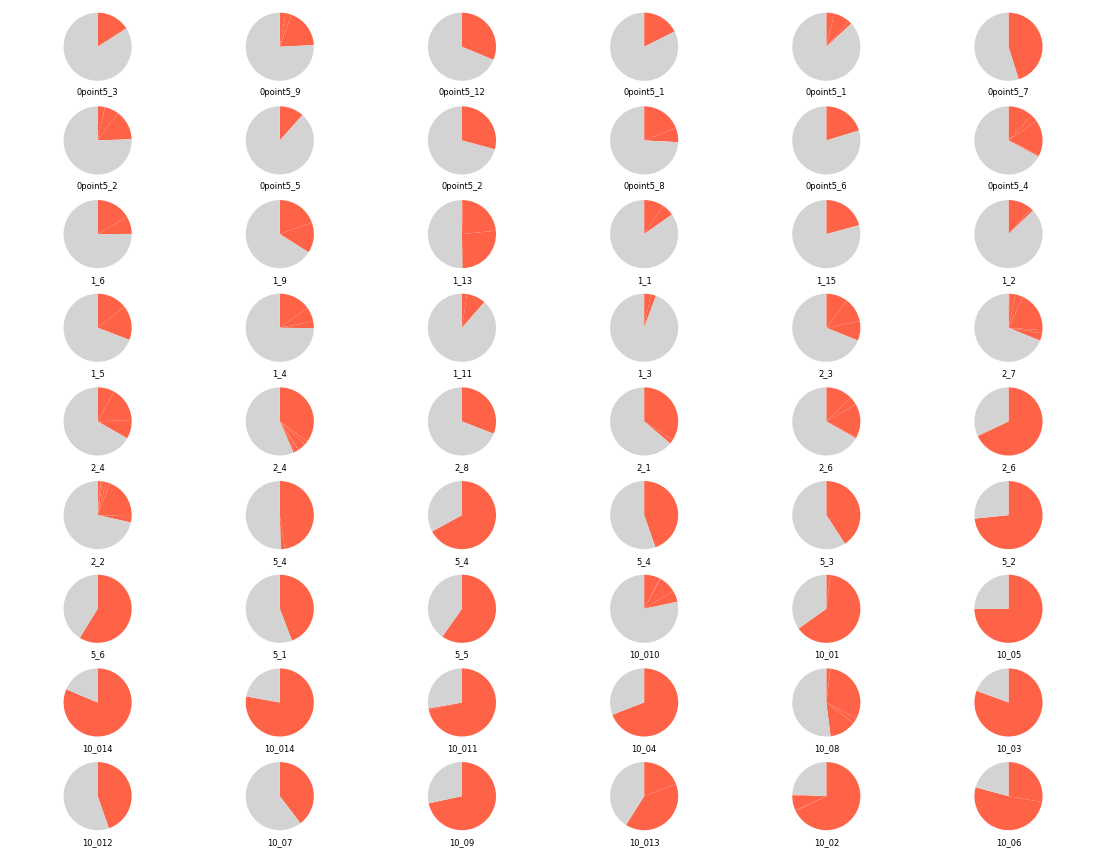

Saved to /Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/custom density with binary clustering/cluster_pie_grid.pdf


In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re



# Load data
df = pd.read_csv('/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/custom density with binary clustering/concat of concats.csv') 



# Extract mixing ratio identifier
df['mixing_ratio'] = df['image'].str.extract(r'_(\d+(?:point\d+)?isto\d+)')

# Unique image identifiers
image_names = df['image'].unique()

def generate_label(image_name):
    ratio_match = re.search(r'_(\d+(?:point\d+)?)(?:isto\d+)', image_name)
    ratio_id = ratio_match.group(1) if ratio_match else "unknown"
    image_match = re.search(r'Image (\d+)', image_name)
    image_id = image_match.group(1) if image_match else "unknown"
    return f'{ratio_id}_{image_id}'

def draw_pie_panel(image_data, ax):
    total_red_volume = image_data['red_channel_ch2_total_volume'].iloc[0]

    # Cluster fractions relative to total
    cluster_fractions = image_data['total_volume'] / total_red_volume if total_red_volume > 0 else []
    cluster_fractions = cluster_fractions.tolist()

    # Add "unclustered" fraction if not fully clustered
    clustered_total = sum(cluster_fractions)
    if clustered_total < 1.0:
        cluster_fractions.append(1.0 - clustered_total)
        colors = ['tomato'] * (len(cluster_fractions) - 1) + ['lightgray']
    else:
        colors = ['tomato'] * len(cluster_fractions)

    # Plot the pie chart
    ax.pie(cluster_fractions, colors=colors, startangle=90, counterclock=False)

    # Remove axis decorations
    ax.axis('equal')
    ax.set_xticks([])
    ax.set_yticks([])

    # Add label below pie
    label = generate_label(image_data['image'].iloc[0])
    ax.text(0, -1.2, label, ha='center', va='top', fontsize=6)

# Layout setup
n_images = len(image_names)
cols = 6
rows = int(np.ceil(n_images / cols))

fig, axes = plt.subplots(rows, cols, figsize=(11, 8.5))
axes = axes.flatten()

for ax, image_name in zip(axes, image_names):
    image_data = df[df['image'] == image_name]
    draw_pie_panel(image_data, ax)

# Hide unused axes
for idx in range(n_images, len(axes)):
    axes[idx].axis('off')

plt.tight_layout(pad=0.5)
plt.show()

# # Save to PDF
# output_path = '/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/custom density with binary clustering/cluster_pie_grid.pdf'
# fig.savefig(output_path, format='pdf')
# print(f"Saved to {output_path}")

0point5isto1
median total volume = 557.68
fraction in clusters = 0.24
1isto1
median total volume = 1333.11
fraction in clusters = 0.23
2isto1
median total volume = 2676.71
fraction in clusters = 0.33
5isto1
median total volume = 1186.46
fraction in clusters = 0.54
10isto1
median total volume = 2665.51
fraction in clusters = 0.72


/var/folders/0d/bvrgm3_11sn91zj4_tx79tl80000gq/T/ipykernel_71026/1432402780.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('mixing_ratio')


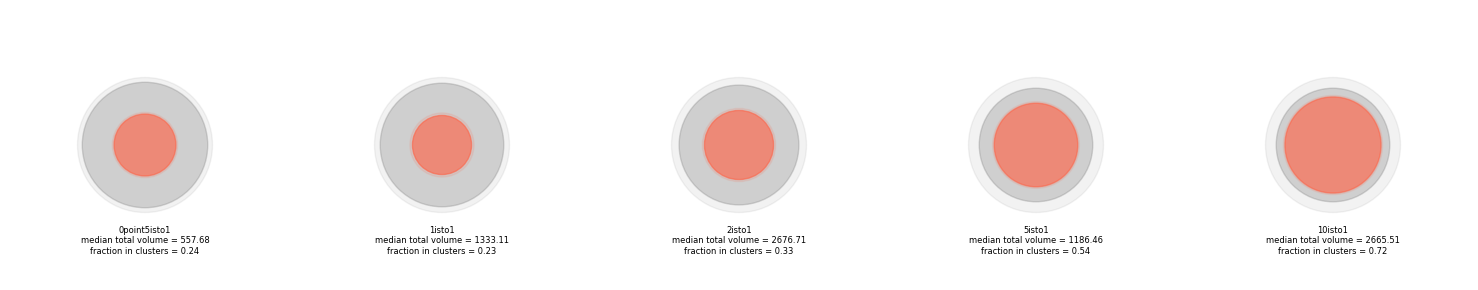

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# Extract mixing ratio
df['mixing_ratio'] = df['image'].str.extract(r'_(\d+(?:point\d+)?isto\d+)')[0]
desired_order = ['0point5isto1', '1isto1', '2isto1', '5isto1', '10isto1']
df['mixing_ratio'] = pd.Categorical(df['mixing_ratio'], categories=desired_order, ordered=True)

grouped = df.groupby('mixing_ratio')
summary_data = []

for ratio, group in grouped:
    if group.empty:
        continue

    red_volumes = []
    clustered_fractions = []

    for image in group['image'].unique():
        image_data = group[group['image'] == image]
        total_red_volume = image_data['red_channel_ch2_total_volume'].iloc[0]
        total_cluster_volume = image_data['total_volume'].sum()

        red_volumes.append(total_red_volume)
        clustered_fractions.append(total_cluster_volume / total_red_volume if total_red_volume > 0 else 0)

    red_volumes = np.array(red_volumes)
    clustered_fractions = np.array(clustered_fractions)

    summary_data.append({
        'mixing_ratio': ratio,
        'median_red_volume': np.median(red_volumes),
        'sem_red_volume': np.std(red_volumes, ddof=1) / np.sqrt(len(red_volumes)),
        'median_cluster_fraction': np.median(clustered_fractions),
        'sem_cluster_fraction': np.std(clustered_fractions, ddof=1) / np.sqrt(len(clustered_fractions)),
    })

# Get global max red volume for consistent scaling across ratios
global_max_red_volume = max(item['median_red_volume'] for item in summary_data)

# Plotting
fig, axes = plt.subplots(1, len(summary_data), figsize=(3 * len(summary_data), 3))
if len(summary_data) == 1:
    axes = [axes]

for ax, data in zip(axes, summary_data):
    ratio_label = data['mixing_ratio']
    median_vol = data['median_red_volume']
    sem_vol = data['sem_red_volume']
    median_cluster_frac = data['median_cluster_fraction']
    sem_cluster_frac = data['sem_cluster_fraction']

    # Area-scaled gray diameter
    gray_diameter = np.sqrt(median_vol / global_max_red_volume)

    # Draw gray median circle
    gray_circle = plt.Circle((0, 0), gray_diameter / 2, color='gray', alpha=0.3)
    ax.add_artist(gray_circle)

    # SEM halo for gray circle
    sem_outer_diameter = np.sqrt((median_vol + sem_vol) / global_max_red_volume)
    halo = plt.Circle((0, 0), sem_outer_diameter / 2, color='gray', alpha=0.1)
    ax.add_artist(halo)

    # Area-scaled tomato diameter (fraction of gray)
    tomato_diameter = gray_diameter * np.sqrt(median_cluster_frac)

    # Draw tomato cluster circle
    tomato_circle = plt.Circle((0, 0), tomato_diameter / 2, color='tomato', alpha=0.6)
    ax.add_artist(tomato_circle)

    # SEM halo for tomato circle
    sem_tomato_outer_diameter = gray_diameter * np.sqrt(median_cluster_frac + sem_cluster_frac)
    tomato_halo = plt.Circle((0, 0), sem_tomato_outer_diameter / 2, color='tomato', alpha=0.1)
    ax.add_artist(tomato_halo)

    ax.set_xlim(-sem_outer_diameter, sem_outer_diameter)
    ax.set_ylim(-sem_outer_diameter, sem_outer_diameter)
    ax.set_aspect('equal')
    ax.axis('off')
    
        # Construct multiline summary text
    summary_text = f"{ratio_label}\n" \
                   f"median total volume = {median_vol:.2f}\n" \
                   f"fraction in clusters = {median_cluster_frac:.2f}"
    
    # Place the text below the diagram
    ax.text(0, -sem_outer_diameter * 0.6, summary_text, ha='center', va='top', fontsize=6)
    print(summary_text)

plt.tight_layout()
plt.show()

# # Optional: Save to PDF
# output_path = '/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/custom density with binary clustering/summary_cluster_mass_distribution.pdf'
# fig.savefig(output_path, format='pdf')
# print(f"Saved to {output_path}")

 # fitness plotting

/var/folders/0d/bvrgm3_11sn91zj4_tx79tl80000gq/T/ipykernel_71026/364350577.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby('mixing_ratio')['red_green_ratio'].agg(['median', 'sem']).reset_index()


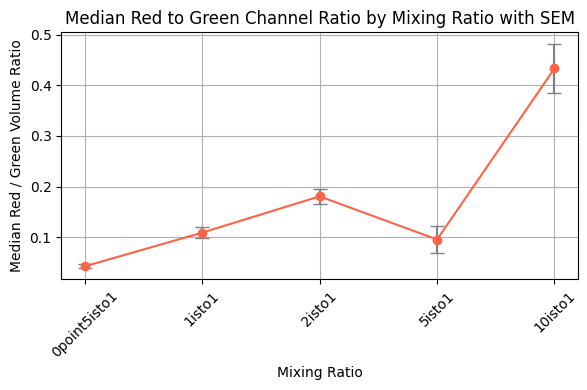

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your uploaded data
df = pd.read_csv('concat of concats.csv')

# Extract mixing ratio as a category
df['mixing_ratio'] = df['image'].str.extract(r'_(\d+(?:point\d+)?isto\d+)')[0]
desired_order = ['0point5isto1', '1isto1', '2isto1', '5isto1', '10isto1']
df['mixing_ratio'] = pd.Categorical(df['mixing_ratio'], categories=desired_order, ordered=True)

# Compute red/green ratio per image
df['red_green_ratio'] = df['red_channel_ch2_total_volume'] / df['green_channel_ch2_total_volume']

# Aggregate to median and SEM per mixing ratio
summary = df.groupby('mixing_ratio')['red_green_ratio'].agg(['median', 'sem']).reset_index()

# Plot
plt.figure(figsize=(6, 4))
plt.errorbar(summary['mixing_ratio'], summary['median'], yerr=summary['sem'],
             fmt='-o', capsize=5, color='tomato', ecolor='gray')

plt.xlabel('Mixing Ratio')
plt.ylabel('Median Red / Green Volume Ratio')
plt.title('Median Red to Green Channel Ratio by Mixing Ratio with SEM')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# distribution scatter of m2/m1

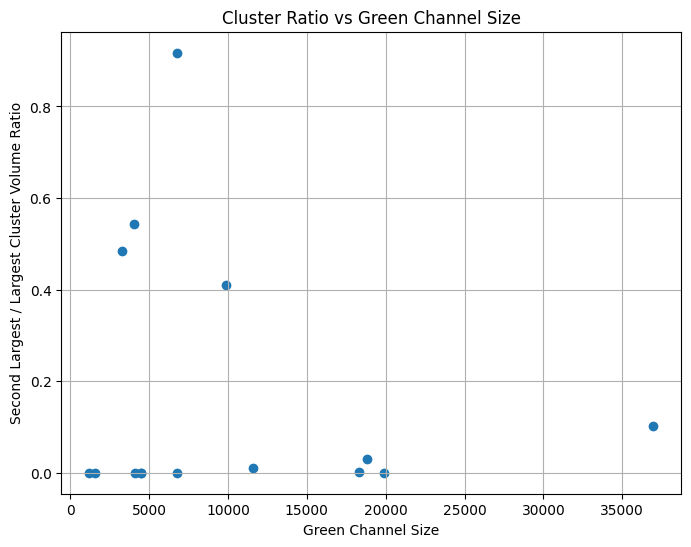

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


#10isto1
# Load the data
df = pd.read_csv('/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/custom density with binary clustering/10isto1concat.csv')

# Ensure numeric type for green channel volume
df['green_channel_ch2_total_volume'] = pd.to_numeric(df['green_channel_ch2_total_volume'], errors='coerce')

# Calculate second-to-first cluster volume ratio for each image
results = []
grouped = df.groupby('image')
for image, group in grouped:
    sorted_volumes = group['total_volume'].sort_values(ascending=False).reset_index(drop=True)
    largest = sorted_volumes.iloc[0]
    second_largest = sorted_volumes.iloc[1] if len(sorted_volumes) > 1 else 0.0
    ratio = second_largest / largest if largest > 0 else 0.0
    green_size = group['green_channel_ch2_total_volume'].iloc[0]
    results.append({'image': image, 'green_size': green_size, 'ratio': ratio})

# Create summary DataFrame
result_df = pd.DataFrame(results)

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(result_df['green_size'], result_df['ratio'])
plt.xlabel('Green Channel Size')
plt.ylabel('Second Largest / Largest Cluster Volume Ratio')
plt.title('Cluster Ratio vs Green Channel Size')
plt.grid(True)
plt.show()

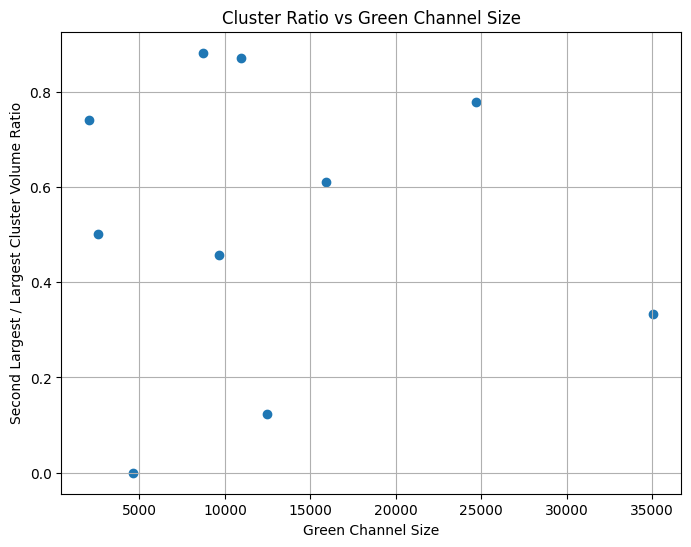

In [7]:
import pandas as pd
import matplotlib.pyplot as plt




#1isto1
# Load the data
df = pd.read_csv('/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/custom density with binary clustering/1isto1concat.csv')

# Ensure numeric type for green channel volume
df['green_channel_ch2_total_volume'] = pd.to_numeric(df['green_channel_ch2_total_volume'], errors='coerce')

# Calculate second-to-first cluster volume ratio for each image
results = []
grouped = df.groupby('image')
for image, group in grouped:
    sorted_volumes = group['total_volume'].sort_values(ascending=False).reset_index(drop=True)
    largest = sorted_volumes.iloc[0]
    second_largest = sorted_volumes.iloc[1] if len(sorted_volumes) > 1 else 0.0
    ratio = second_largest / largest if largest > 0 else 0.0
    green_size = group['green_channel_ch2_total_volume'].iloc[0]
    results.append({'image': image, 'green_size': green_size, 'ratio': ratio})

# Create summary DataFrame
result_df = pd.DataFrame(results)

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(result_df['green_size'], result_df['ratio'])
plt.xlabel('Green Channel Size')
plt.ylabel('Second Largest / Largest Cluster Volume Ratio')
plt.title('Cluster Ratio vs Green Channel Size')
plt.grid(True)
plt.show()

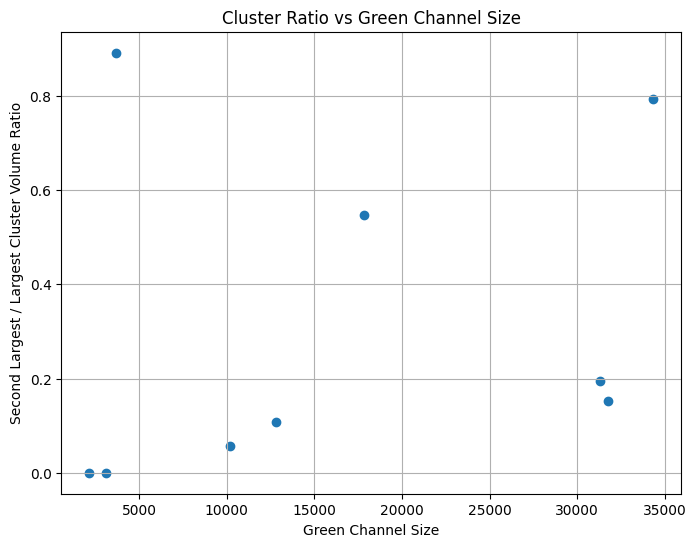

In [9]:
import pandas as pd
import matplotlib.pyplot as plt




#1isto1
# Load the data
df = pd.read_csv('/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/custom density with binary clustering/2isto1concat.csv')

# Ensure numeric type for green channel volume
df['green_channel_ch2_total_volume'] = pd.to_numeric(df['green_channel_ch2_total_volume'], errors='coerce')

# Calculate second-to-first cluster volume ratio for each image
results = []
grouped = df.groupby('image')
for image, group in grouped:
    sorted_volumes = group['total_volume'].sort_values(ascending=False).reset_index(drop=True)
    largest = sorted_volumes.iloc[0]
    second_largest = sorted_volumes.iloc[1] if len(sorted_volumes) > 1 else 0.0
    ratio = second_largest / largest if largest > 0 else 0.0
    green_size = group['green_channel_ch2_total_volume'].iloc[0]
    results.append({'image': image, 'green_size': green_size, 'ratio': ratio})

# Create summary DataFrame
result_df = pd.DataFrame(results)

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(result_df['green_size'], result_df['ratio'])
plt.xlabel('Green Channel Size')
plt.ylabel('Second Largest / Largest Cluster Volume Ratio')
plt.title('Cluster Ratio vs Green Channel Size')
plt.grid(True)
plt.show()

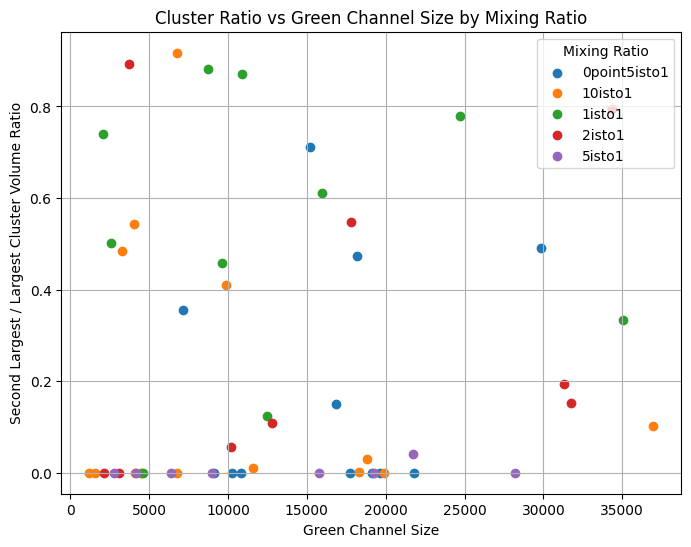

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/custom density with binary clustering/concat of concats.csv')

# Extract mixing ratio
df['mixing_ratio'] = df['image'].str.extract(r'_(\d+(?:point\d+)?isto\d+)')

# Ensure numeric type for green channel volume
df['green_channel_ch2_total_volume'] = pd.to_numeric(df['green_channel_ch2_total_volume'], errors='coerce')

# Calculate second-to-first cluster volume ratio for each image
results = []
grouped = df.groupby('image')
for image, group in grouped:
    sorted_volumes = group['total_volume'].sort_values(ascending=False).reset_index(drop=True)
    largest = sorted_volumes.iloc[0]
    second_largest = sorted_volumes.iloc[1] if len(sorted_volumes) > 1 else 0.0
    ratio = second_largest / largest if largest > 0 else 0.0
    green_size = group['green_channel_ch2_total_volume'].iloc[0]
    mixing_ratio = group['mixing_ratio'].iloc[0]
    results.append({'image': image, 'green_size': green_size, 'ratio': ratio, 'mixing_ratio': mixing_ratio})

# Create summary DataFrame
result_df = pd.DataFrame(results)

# Plot the results with hue by mixing_ratio
plt.figure(figsize=(8, 6))
for label, group in result_df.groupby('mixing_ratio'):
    plt.scatter(group['green_size'], group['ratio'], label=label)

plt.xlabel('Green Channel Size')
plt.ylabel('Second Largest / Largest Cluster Volume Ratio')
plt.title('Cluster Ratio vs Green Channel Size by Mixing Ratio')
plt.legend(title='Mixing Ratio')
plt.grid(True)
plt.show()

# old old data analysis

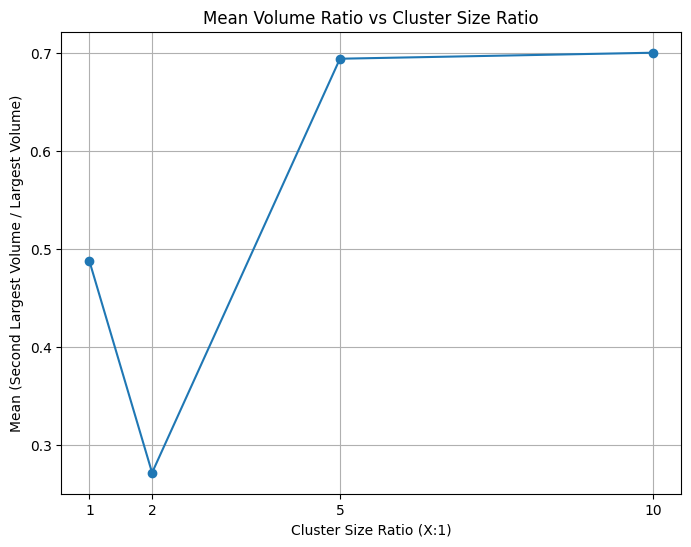

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
file_path = '/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/density analysis/new analysis with new data/concat_all_summaries_forweeklyreport.csv'
df = pd.read_csv(file_path)

# Step 1: Clean and extract numeric ratio
df['ratio_numeric'] = df['ratio'].str.extract(r'(\d+)').astype(float)

# Step 2: Find largest and second largest clusters per image
# Sort by image and volume descending
df_sorted = df.sort_values(['image', 'total_volume'], ascending=[True, False])

# Step 3: For each image, take the top 2 clusters
top2_clusters = df_sorted.groupby('image').head(2)

# Step 4: Split into largest and second largest
largest = top2_clusters.groupby('image').nth(0).reset_index()
second_largest = top2_clusters.groupby('image').nth(1).reset_index()

# Step 5: Merge them together
volume_comparison = pd.merge(
    largest[['image', 'ratio_numeric', 'total_volume']],
    second_largest[['image', 'total_volume']],
    on='image',
    suffixes=('_largest', '_second_largest')
)

# Step 6: Calculate the volume ratio
volume_comparison['volume_ratio'] = volume_comparison['total_volume_second_largest'] / volume_comparison['total_volume_largest']

# Step 7: Group by ratio_numeric and calculate mean volume ratio
mean_ratios = volume_comparison.groupby('ratio_numeric')['volume_ratio'].median().reset_index()

# Step 8: Plot
plt.figure(figsize=(8,6))
plt.plot(mean_ratios['ratio_numeric'], mean_ratios['volume_ratio'], marker='o')
plt.xlabel('Cluster Size Ratio (X:1)')
plt.ylabel('Mean (Second Largest Volume / Largest Volume)')
plt.title('Mean Volume Ratio vs Cluster Size Ratio')
plt.grid(True)
plt.xticks(mean_ratios['ratio_numeric'])  # Ensure ticks match available ratios
plt.show()

/var/folders/0d/bvrgm3_11sn91zj4_tx79tl80000gq/T/ipykernel_25084/331013077.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = volume_comparison.groupby(['volume_bin', 'ratio_numeric'])['volume_ratio'].mean().reset_index()


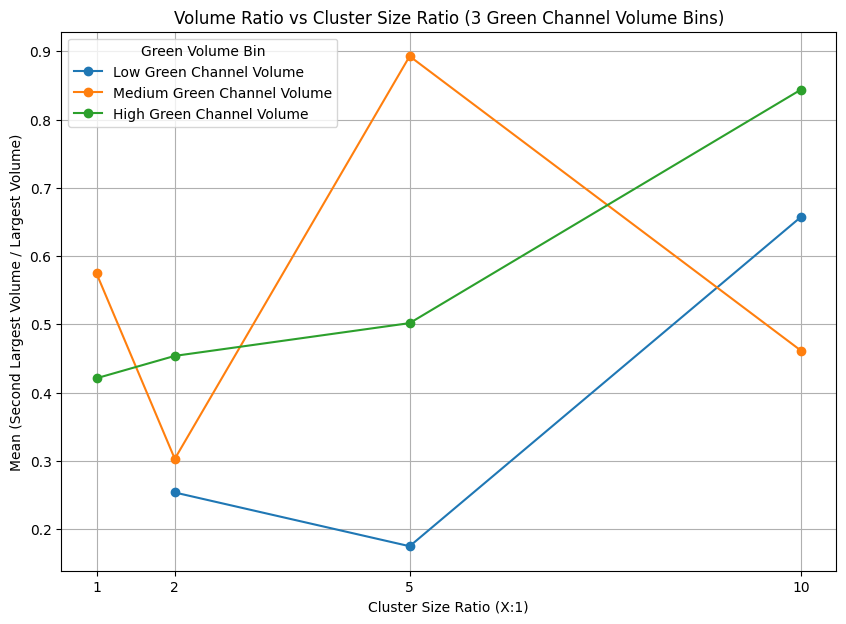

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
file_path = 'concat_all_summaries_forweeklyreport.csv'
df = pd.read_csv(file_path)

# Step 1: Clean ratio column
df['ratio_numeric'] = df['ratio'].str.extract(r'(\d+)').astype(float)

# Step 2: Create 3 bins based on green_channel_ch2_total volume globally
bin_labels = ['Low', 'Medium', 'High']
df['volume_bin'] = pd.qcut(df['green_channel_ch2_total volume'], q=3, labels=bin_labels)

# Step 3: Sort by image and total_volume
df_sorted = df.sort_values(['image', 'total_volume'], ascending=[True, False])

# Step 4: Find top 2 clusters per image
top2_clusters = df_sorted.groupby('image').head(2)

# Step 5: Split into largest and second largest
largest = top2_clusters.groupby('image').nth(0).reset_index()
second_largest = top2_clusters.groupby('image').nth(1).reset_index()

# Merge largest and second largest
volume_comparison = pd.merge(
    largest[['image', 'ratio_numeric', 'total_volume', 'volume_bin']],
    second_largest[['image', 'total_volume']],
    on='image',
    suffixes=('_largest', '_second_largest')
)

# Step 6: Calculate volume ratio
volume_comparison['volume_ratio'] = volume_comparison['total_volume_second_largest'] / volume_comparison['total_volume_largest']

# Step 7: Group by volume bin and ratio
grouped = volume_comparison.groupby(['volume_bin', 'ratio_numeric'])['volume_ratio'].mean().reset_index()

# Step 8: Plot
plt.figure(figsize=(10,7))
for bin_label in bin_labels:
    subset = grouped[grouped['volume_bin'] == bin_label]
    plt.plot(subset['ratio_numeric'], subset['volume_ratio'], marker='o', label=f'{bin_label} Green Channel Volume')

plt.xlabel('Cluster Size Ratio (X:1)')
plt.ylabel('Mean (Second Largest Volume / Largest Volume)')
plt.title('Volume Ratio vs Cluster Size Ratio (3 Green Channel Volume Bins)')
plt.legend(title='Green Volume Bin')
plt.grid(True)
plt.xticks(sorted(volume_comparison['ratio_numeric'].unique()))
plt.show()

In [1]:
#new analysis

In [9]:
import pandas as pd

# Path to your CSV file
file_path = '/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/density analysis/new analysis with new data/concat_all_summaries_forweeklyreport.csv'

# Load the data
df = pd.read_csv(file_path)

In [10]:


# Prepare list to collect rows for the new DataFrame
result_rows = []

# Group by image
grouped = df.groupby('image')

for image_name, group in grouped:
    if group.shape[0] >= 2:
        # Sort clusters by total_volume descending
        sorted_group = group.sort_values(by='total_volume', ascending=False)
        
        # Extract required values
        largest = sorted_group.iloc[0]['total_volume']
        second_largest = sorted_group.iloc[1]['total_volume']
        green_volume = sorted_group.iloc[0]['green_channel_ch2_total volume']  # Column name with space
        
        # Append the row
        result_rows.append({
            'image': image_name,
            'largest_cluster_volume': largest,
            'second_largest_cluster_volume': second_largest,
            'green_channel_volume': green_volume
        })

# Create the final DataFrame
summary_df = pd.DataFrame(result_rows)

# Save to CSV
# output_path = "/path/to/output/image_cluster_summary_two_or_more.csv"  # Update path as needed
summary_df.to_csv('newdensitysummary_10isto1.csv', index=False)

In [22]:
csvfilestoconcat=['/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/density analysis/new analysis with new data/newdensitysummary_1isto1.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/density analysis/new analysis with new data/newdensitysummary_2isto1.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/density analysis/new analysis with new data/newdensitysummary_5isto1.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/density analysis/new analysis with new data/newdensitysummary_10isto1.csv']

In [23]:
import pandas as pd

# Read and concatenate all CSVs
dfs = [pd.read_csv(file) for file in csvfilestoconcat]
concat_df = pd.concat(dfs, ignore_index=True)

# Save the concatenated DataFrame to a new CSV file
output_path = '/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/density analysis/new analysis with new data/concat_density_summary.csv'
concat_df.to_csv(output_path, index=False)

print(f"Concatenated CSV saved to: {output_path}")

Concatenated CSV saved to: /Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/density analysis/new analysis with new data/concat_density_summary.csv


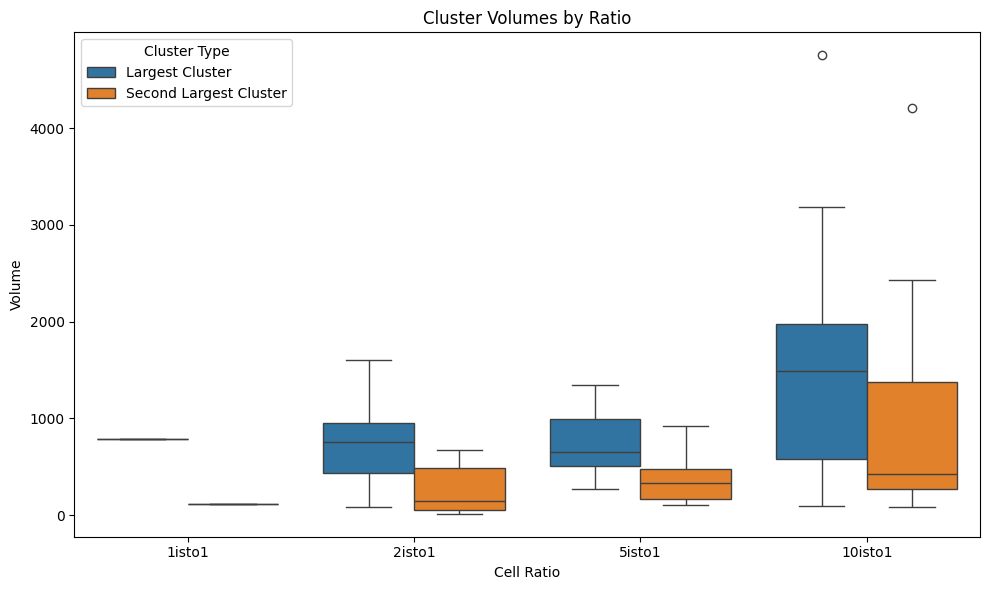

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("final_concat_density_summary.csv")  # Update this path if needed

# Melt the DataFrame to long format for seaborn boxplot
df_melted = df.melt(
    id_vars=['ratio'],
    value_vars=['largest_cluster_volume', 'second_largest_cluster_volume'],
    var_name='Cluster Type',
    value_name='Volume'
)

# Rename for cleaner x-axis labels
df_melted['Cluster Type'] = df_melted['Cluster Type'].replace({
    'largest_cluster_volume': 'Largest Cluster',
    'second_largest_cluster_volume': 'Second Largest Cluster'
})

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_melted, x='ratio', y='Volume', hue='Cluster Type')
plt.title('Cluster Volumes by Ratio')
plt.xlabel('Cell Ratio')
plt.ylabel('Volume')
plt.legend(title='Cluster Type')
plt.tight_layout()
plt.show()

<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
/var/folders/0d/bvrgm3_11sn91zj4_tx79tl80000gq/T/ipykernel_50379/2487416840.py:12: SyntaxWarning: invalid escape sequence '\d'
  mean_ratios['ratio_order'] = mean_ratios['ratio'].str.extract('(\d+)').astype(int)


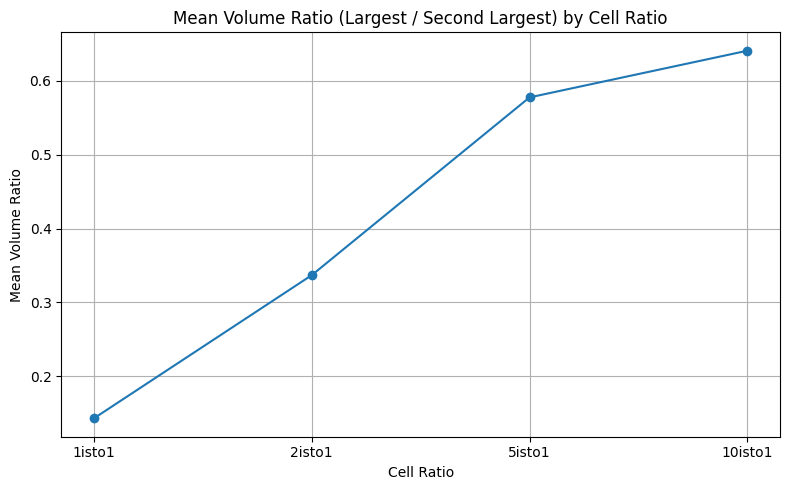

In [29]:
 import pandas as pd
import matplotlib.pyplot as plt


# Calculate volume ratio
# df['volume_ratio'] = df['largest_cluster_volume'] / df['second_largest_cluster_volume']
df['volume_ratio'] = df['second_largest_cluster_volume']/df['largest_cluster_volume'] 
# Compute mean ratio for each condition
mean_ratios = df.groupby('ratio')['volume_ratio'].mean().reset_index()

# Optional: Sort ratios numerically if format is like '1isto1', '2isto1', etc.
mean_ratios['ratio_order'] = mean_ratios['ratio'].str.extract('(\d+)').astype(int)
mean_ratios = mean_ratios.sort_values(by='ratio_order')

# Plot
plt.figure(figsize=(8, 5))
plt.plot(mean_ratios['ratio'], mean_ratios['volume_ratio'], marker='o', linestyle='-')
plt.title('Mean Volume Ratio (Largest / Second Largest) by Cell Ratio')
plt.xlabel('Cell Ratio')
plt.ylabel('Mean Volume Ratio')
plt.grid(True)
plt.tight_layout()
plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\d'
<>:17: SyntaxWarning: invalid escape sequence '\d'
/var/folders/0d/bvrgm3_11sn91zj4_tx79tl80000gq/T/ipykernel_50379/762276483.py:17: SyntaxWarning: invalid escape sequence '\d'
  mean_ratios['x'] = mean_ratios['ratio'].str.extract('(\d+)').astype(int)
/var/folders/0d/bvrgm3_11sn91zj4_tx79tl80000gq/T/ipykernel_50379/762276483.py:27: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(sigmoid, x_data, y_data, maxfev=10000)


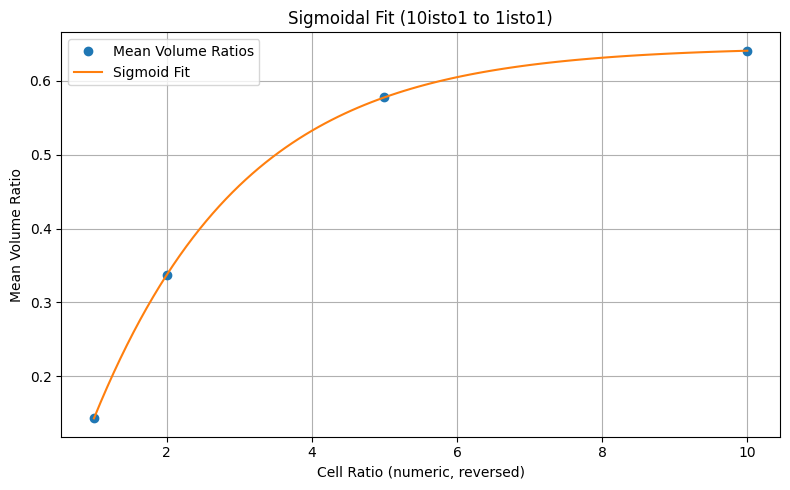

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# # Load the CSV file
# df = pd.read_csv("/path/to/final_concat_density_summary.csv")  # Replace with your actual path

# Calculate volume ratio
# df['volume_ratio'] = df['largest_cluster_volume'] / df['second_largest_cluster_volume']
df['volume_ratio'] = df['second_largest_cluster_volume']/df['largest_cluster_volume'] 

# Compute mean volume ratio per ratio group
mean_ratios = df.groupby('ratio')['volume_ratio'].mean().reset_index()

# Extract numeric ratio and sort in reverse (10 to 1)
mean_ratios['x'] = mean_ratios['ratio'].str.extract('(\d+)').astype(int)
mean_ratios = mean_ratios.sort_values(by='x', ascending=False)

# Define sigmoid function
def sigmoid(x, a, b, c, d):
    return d + (a - d) / (1 + np.exp(-b * (x - c)))

# Fit the sigmoid curve
x_data = mean_ratios['x'].values
y_data = mean_ratios['volume_ratio'].values
popt, _ = curve_fit(sigmoid, x_data, y_data, maxfev=10000)

# Generate smooth x values for prediction
x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit = sigmoid(x_fit, *popt)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x_data, y_data, 'o', label='Mean Volume Ratios')
plt.plot(x_fit, y_fit, '-', label='Sigmoid Fit')
plt.xlabel('Cell Ratio (numeric, reversed)')
plt.ylabel('Mean Volume Ratio')
plt.title('Sigmoidal Fit (10isto1 to 1isto1)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# file operations 

## renaming from ch2 to ch1 in the column header

In [ ]:
"""
some previously when i computed and added the total red channel volume in the "...cluster volume summary csv",
i mistakenly called the column "red_channel_ch2_total_volume". the following cells correct to ch1 instead
"""

In [3]:
# first the dry run to see which files will be changed 

# Cell 1 of 2: imports & helper

import os
import pandas as pd

def find_files_to_modify(root_dir):
    """
    Walk root_dir, find all *_cluster_volume_summary.csv files
    that have a 'red_channel_ch2_total_volume' column.
    Return a list of their full paths.
    """
    matches = []
    for dirpath, _, filenames in os.walk(root_dir):
        for fname in filenames:
            if fname.endswith("_cluster_volume_summary.csv"):
                full_path = os.path.join(dirpath, fname)
                try:
                    df = pd.read_csv(full_path, nrows=0)  # only load header
                except Exception as e:
                    print(f"⚠️  Could not read {full_path}: {e}")
                    continue

                if "red_channel_ch2_total_volume" in df.columns:
                    matches.append(full_path)
    return matches

In [4]:
# Cell 2 of 2 : run & report
import os
import datetime

root_dir = '/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging'

to_modify = find_files_to_modify(root_dir)

for full_path in to_modify:
    filename = os.path.basename(full_path)
    mtime = os.path.getmtime(full_path)
    # convert to local datetime
    dt = datetime.datetime.fromtimestamp(mtime)
    print(f"{filename} ---- {dt.strftime('%Y-%m-%d %H:%M:%S')}")

print(f"\nTotal files to modify: {len(to_modify)}")

Image 010_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv ---- 2025-05-13 14:59:07
Image 01_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv ---- 2025-05-13 14:59:07
Image 05_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv ---- 2025-05-13 14:59:07
Image 014_10isto1_04212025_pos01_t01_filtered_roi.ome_colony1_cluster_volume_summary.csv ---- 2025-05-13 14:59:07
Image 014_10isto1_04212025_pos01_t01_filtered_roi.ome_colony2_cluster_volume_summary.csv ---- 2025-05-13 14:59:07
Image 011_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv ---- 2025-05-13 14:59:07
Image 04_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv ---- 2025-05-13 14:59:07
Image 08_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv ---- 2025-05-13 14:59:07
Image 03_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv ---- 2025-05-13 14:59:07
Image 012_10isto1_04212025_pos01_t0

In [8]:
"""
cheked in the finder the above number is correct. except 0point2isto1 files
""";

In [10]:
"""
now in the following cell let us rename this ch2 to ch1 to coorectly reflect the channel
""";

In [11]:
# Cell 1 of 2: imports & function definition
import os
import pandas as pd

def rename_volume_column_and_collect(root_dir):
    """
    Walk root_dir for files ending in '_cluster_volume_summary.csv';
    if they contain 'red_channel_ch2_total_volume', rename it to
    'red_channel_ch1_total_volume', save, and collect the filename.
    Returns a list of filenames (not full paths) that were modified.
    """
    modified = []
    
    for dirpath, _, filenames in os.walk(root_dir):
        for fname in filenames:
            if fname.endswith("_cluster_volume_summary.csv"):
                full_path = os.path.join(dirpath, fname)
                try:
                    df = pd.read_csv(full_path)
                except Exception as e:
                    print(f"⚠️ Could not read {full_path}: {e}")
                    continue

                if "red_channel_ch2_total_volume" in df.columns:
                    df.rename(
                        columns={"red_channel_ch2_total_volume": "red_channel_ch1_total_volume"},
                        inplace=True
                    )
                    try:
                        df.to_csv(full_path, index=False)
                        modified.append(fname)
                        print(f"✅ Renamed in: {fname}")
                    except Exception as e:
                        print(f"⚠️ Could not write {full_path}: {e}")
    return modified

In [12]:
# Cell 2: run it & write the report (filenames only)
root_dir = '/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging'
report_path  = '/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/extended data s analysis'   # ← name of the output text file

modified_files = rename_volume_column_and_collect(root_dir)

# write just the filenames to the report
with open(report_path, "w") as rep:
    for fname in modified_files:
        rep.write(fname + "\n")

print(f"\n📄  Done! {len(modified_files)} files modified.")
print(f"Report written to: {report_path}")

✅ Renamed in: Image 010_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv
✅ Renamed in: Image 01_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv
✅ Renamed in: Image 05_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv
✅ Renamed in: Image 014_10isto1_04212025_pos01_t01_filtered_roi.ome_colony1_cluster_volume_summary.csv
✅ Renamed in: Image 014_10isto1_04212025_pos01_t01_filtered_roi.ome_colony2_cluster_volume_summary.csv
✅ Renamed in: Image 011_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv
✅ Renamed in: Image 04_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv
✅ Renamed in: Image 08_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv
✅ Renamed in: Image 03_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv
✅ Renamed in: Image 012_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv
✅ Renamed in: Image 07_10isto1_04212025

IsADirectoryError: [Errno 21] Is a directory: '/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/extended data s analysis'

## to add the total red ch volume to cluster volume summary csv

In [14]:
# running this on the second batch of files so only does it if the column with red ch vol total does not exist

In [28]:
# dry run to get file names cell 1 of 2


# Cell 1: imports & helper
import os
import pandas as pd
from pathlib import Path

def find_summaries_to_update(base_dir):
    """
    Walk base_dir for 'txt_output' folders, look for
    '..._cluster_volume_summary.csv' files, and return
    the filenames of those missing 'red_channel_ch1_total_volume'.
    """
    to_modify = []
    for root, dirs, files in os.walk(base_dir):
        if Path(root).name != 'txt_output':
            continue

        # find the summary CSV(s)
        for fname in files:
            if fname.endswith('cluster_volume_summary.csv'):
                summary_path = Path(root) / fname
                try:
                    df = pd.read_csv(summary_path, nrows=0)  # header only
                except Exception as e:
                    print(f"⚠️  Could not read {fname}: {e}")
                    continue

                if 'red_channel_ch1_total_volume' not in df.columns:
                    to_modify.append(fname)
    return to_modify

In [27]:
# dry run Cell 2 of 2 : run the dry‐run and print results
base_dir = Path('/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/2isto1/2isto1_05202025/Image 11_2isto1_05202025/tif file_Image 11_2isto1_05202025/Image 11_2isto1_05202025_pos01_t01_filtered_roi.ome/data/txt_output')

pending = find_summaries_to_update(base_dir)

for name in pending:
    print(name)

print(f"\nTotal files that would be updated: {len(pending)}")

Image 11_2isto1_05202025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv

Total files that would be updated: 1


In [18]:
""" in the following code let us add the red ch sum in the cluster vol summary csv
after checking that the summary file does not already have that column""";

In [31]:
import os
import pandas as pd
from pathlib import Path

# Set the base directory where your data lives
base_dir = Path(base_dir = Path('/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/2isto1/2isto1_05202025/Image 11_2isto1_05202025/tif file_Image 11_2isto1_05202025/Image 11_2isto1_05202025_pos01_t01_filtered_roi.ome/data/txt_output')

for root, dirs, files in os.walk(base_dir):
    current_path = Path(root)
    if current_path.name != 'txt_output':
        continue

    # Locate the summary file
    summary_files = [f for f in files if f.endswith('cluster_volume_summary.csv')]
    if not summary_files:
        print(f"No cluster_volume_summary.csv in {current_path}")
        continue
    summary_path = current_path / summary_files[0]

    # Load summary and check if column already exists
    try:
        df_summary = pd.read_csv(summary_path)
    except Exception as e:
        print(f"Failed to read {summary_path}: {e}")
        continue

    if 'red_channel_ch1_total_volume' in df_summary.columns:
        print(f"→ Column already present in {summary_path.name}; skipping.")
        continue

    # Locate the pos1_ch1 file to get the red-channel sum
    pos1_files = [f for f in files if f.endswith('pos1_ch1_frame000001.csv')]
    if not pos1_files:
        print(f"No pos1_ch1_frame000001.csv in {current_path}")
        continue
    pos1_path = current_path / pos1_files[0]

    try:
        df_pos1 = pd.read_csv(pos1_path, skiprows=[1])
        red_channel_sum = df_pos1['Shape_Volume'].sum()
    except Exception as e:
        print(f"Failed to read or sum {pos1_path}: {e}")
        continue

    # Insert the new column just before 'Clustering_Method'
    cols = list(df_summary.columns)
    insert_at = cols.index('Clustering_Method')
    df_summary.insert(insert_at, 'red_channel_ch1_total_volume', red_channel_sum)

    # Save back to CSV
    try:
        df_summary.to_csv(summary_path, index=False)
        print(f"✅ Updated {summary_path.name}")
    except Exception as e:
        print(f"Failed to write {summary_path}: {e}")

SyntaxError: '(' was never closed (1089936469.py, line 6)

In [ ]:
# older first time addition -- same as above but does not look for existing columns
#adds the red channel data post facto
# gets from ch1 file and adds to summary file in all txt_output folders in a given path recursively

import os
import pandas as pd
from pathlib import Path

# Set the base directory where "1isto1__04222025" is located
base_dir = Path('/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point5isto1 wttomut 04282025/')

# Walk through all subdirectories to find txt_output folders
for root, dirs, files in os.walk(base_dir):
    current_path = Path(root)
    if current_path.name == 'txt_output':
        # Find the "pos1_ch1_frame000001.csv" file
        pos1_files = [f for f in files if f.endswith('pos1_ch1_frame000001.csv')]
        if not pos1_files:
            print(f"No pos1_ch1_frame000001.csv found in {current_path}\n")
            continue  # Skip if the file is missing

        # Read the Shape_Volume data, skipping the second row (index 1)
        pos1_path = current_path / pos1_files[0]
        try:
            df_pos1 = pd.read_csv(pos1_path, skiprows=[1])
            red_channel_sum = df_pos1['Shape_Volume'].sum()
        except Exception as e:
            print(f"Failed reading {pos1_path}: {e}\n")
            continue

        # Find the cluster_volume_summary.csv file
        summary_files = [f for f in files if f.endswith('cluster_volume_summary.csv')]
        if not summary_files:
            print(f"No cluster_volume_summary.csv found in {current_path}\n")
            continue  # Skip if the file is missing

        summary_path = current_path / summary_files[0]
        try:
            df_summary = pd.read_csv(summary_path)

            # Insert the new column before the last one (Clustering_Method)
            col_list = list(df_summary.columns)
            insert_index = col_list.index('Clustering_Method')
            df_summary.insert(insert_index, 'red_channel_ch1_total_volume', red_channel_sum)

            # Overwrite the original file
            df_summary.to_csv(summary_path, index=False)
            print(f"Updated {summary_path}\n")
        except Exception as e:
            print(f"Failed processing {summary_path}: {e}\n")

## concatanations

In [14]:
import os
import pandas as pd

def concatcsvs(input_files_list=None, input_files_path=None, output_dir=None):
    all_csvs = []

    if input_files_list:
        files_to_read = input_files_list
    elif input_files_path:
        files_to_read = [os.path.join(input_files_path, f) for f in os.listdir(input_files_path) if f.endswith('.csv')]
    else:
        raise ValueError("You must provide either input_files_list or input_files_path.")

    if not output_dir:
        raise ValueError("You must specify an output_dir.")

    output_file_name = input("Enter the output file name (with .csv extension): ")
    output_path = os.path.join(output_dir, output_file_name)

    for file_path in files_to_read:
        try:
            df = pd.read_csv(file_path)
            all_csvs.append(df)
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

    if all_csvs:
        final_df = pd.concat(all_csvs, ignore_index=True)
        final_df.to_csv(output_path, index=False)
        print(f"Concatenated CSV saved to {output_path}")
    else:
        print("No CSV files were concatenated.")



In [20]:
#10isto1 file paths
input_files_list = '/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_06052025/Image 1_10isto1_06052025/tif file_Image 1_10isto1_06052025/Image 1_10isto1_06052025_pos01_t01_filtered_roi.ome/data/txt_output/Image 1_10isto1_06052025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_06082025/Image 12_10isto1_06082025/tif file_Image 12_colony2_10isto1_06082025/Image 12_10isto1_06082025_colony2_pos01_t01_filtered_roi.ome/data/txt_output/Image 12_10isto1_06082025_colony2_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_06082025/Image 12_10isto1_06082025/tif file_Image 12_colony1_10isto1_06082025/Image 12_10isto1_06082025_colony1_pos01_t01_filtered_roi.ome/data/txt_output/Image 12_10isto1_06082025_colony1_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_06082025/Image 7_10isto1_06082025/tif file_Image 7_10isto1_06082025/Image 7_10isto1_06082025_pos01_t01_filtered_roi.ome/data/txt_output/Image 7_10isto1_06082025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_06082025/Image 16_10isto1_06082025/tif file_Image 16_10isto1_06082025/Image 16_10isto1_06082025_pos01_t01_filtered_roi.ome/data/txt_output/Image 16_10isto1_06082025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_06082025/Image 3_10isto1_06082025/tif file_Image 3_10isto1_06082025/Image 3_10isto1_06082025_pos01_t01_filtered_roi.ome/data/txt_output/Image 3_10isto1_06082025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_06082025/Image 8_10isto1_06082025/tif file_Image 8_10isto1_06082025/Image 8_10isto1_06082025_pos01_t01_filtered_roi.ome/data/txt_output/Image 8_10isto1_06082025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_06082025/Image 6_10isto1_06082025/tif file_Image 6_10isto1_06082025/Image 6_10isto1_06082025_pos01_t01_filtered_roi.ome/data/txt_output/Image 6_10isto1_06082025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_06082025/Image 13_10isto1_06082025/tif file_Image 13_colony1_10isto1_06082025/Image 13_10isto1_06082025_colony1_pos01_t01_filtered_roi.ome/data/txt_output/Image 13_10isto1_06082025_colony1_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_06082025/Image 2_10isto1_06082025/tif file_Image 2_10isto1_06082025/Image 2_10isto1_06082025_pos01_t01_filtered_roi.ome/data/txt_output/Image 2_10isto1_06082025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_06082025/Image 17_10isto1_06082025/tif file_Image 17_colony2_10isto1_06082025/Image 17_10isto1_06082025_colony2_pos01_t01_filtered_roi.ome/data/txt_output/Image 17_10isto1_06082025_colony2_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_06082025/Image 17_10isto1_06082025/tif file_Image 17_colony1_10isto1_06082025/Image 17_10isto1_06082025_colony1_pos01_t01_filtered_roi.ome/data/txt_output/Image 17_10isto1_06082025_colony1_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_06082025/Image 9_10isto1_06082025/tif file_Image 9_10isto1_06082025/Image 9_10isto1_06082025_pos01_t01_filtered_roi.ome/data/txt_output/Image 9_10isto1_06082025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_06082025/Image 5_10isto1_06082025/tif file_Image 5_10isto1_06082025/Image 5_10isto1_06082025_pos01_t01_filtered_roi.ome/data/txt_output/Image 5_10isto1_06082025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_06082025/Image 10_10isto1_06082025/tif file_Image 10_10isto1_06082025/Image 10_10isto1_06082025_pos01_t01_filtered_roi.ome/data/txt_output/Image 10_10isto1_06082025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_06082025/Image 1_10isto1_06082025/tif file_Image 1_10isto1_06082025/Image 1_10isto1_06082025_pos01_t01_filtered_roi.ome/data/txt_output/Image 1_10isto1_06082025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_06082025/Image 14_10isto1_06082025/tif file_Image 14_10isto1_06082025/Image 14_10isto1_06082025_pos01_t01_filtered_roi.ome/data/txt_output/Image 14_10isto1_06082025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_06082025/Image 11_10isto1_06082025/tif file_Image 11_10isto1_06082025/Image 11_10isto1_06082025_pos01_t01_filtered_roi.ome/data/txt_output/Image 11_10isto1_06082025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_06082025/Image 4_10isto1_06082025/tif file_Image 4_10isto1_06082025/Image 4_10isto1_06082025_pos01_t01_filtered_roi.ome/data/txt_output/Image 4_10isto1_06082025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_06082025/Image 15_10isto1_06082025/tif file_Image 15_10isto1_06082025/Image 15_10isto1_06082025_pos01_t01_filtered_roi.ome/data/txt_output/Image 15_10isto1_06082025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_04212025/Image 06_10isto1_04212025/tif file_Image 06_10isto1_04212025/Image 06_10isto1_04212025_pos01_t01_filtered_roi.ome/data/txt_output/Image 06_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_04212025/Image 02_10isto1_04212025/tif file_Image 02_10isto1_04212025/Image 02_10isto1_04212025_pos01_t01_filtered_roi.ome/data/txt_output/Image 02_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_04212025/Image 013_10isto1_04212025/tif file_Image 013_10isto1_04212025/Image 013_10isto1_04212025_pos01_t01_filtered_roi.ome/data/txt_output/Image 013_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_04212025/Image 09_10isto1_04212025/tif file_Image 09_10isto1_04212025/Image 09_10isto1_04212025_pos01_t01_filtered_roi.ome/data/txt_output/Image 09_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_04212025/Image 07_10isto1_04212025/tif file_Image 07_10isto1_04212025/Image 07_10isto1_04212025_pos01_t01_filtered_roi.ome/data/txt_output/Image 07_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_04212025/Image 012_10isto1_04212025/tif file_Image 012_10isto1_04212025/Image 012_10isto1_04212025_pos01_t01_filtered_roi.ome/data/txt_output/Image 012_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_04212025/Image 03_10isto1_04212025/tif file_Image 03_10isto1_04212025/Image 03_10isto1_04212025_pos01_t01_filtered_roi.ome/data/txt_output/Image 03_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_04212025/Image 08_10isto1_04212025/tif file_Image 08_10isto1_04212025/Image 08_10isto1_04212025_pos01_t01_filtered_roi.ome/data/txt_output/Image 08_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_04212025/Image 04_10isto1_04212025/tif file_Image 04_10isto1_04212025/Image 04_10isto1_04212025_pos01_t01_filtered_roi.ome/data/txt_output/Image 04_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_04212025/Image 011_10isto1_04212025/tif file_Image 011_10isto1_04212025/Image 011_10isto1_04212025_pos01_t01_filtered_roi.ome/data/txt_output/Image 011_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_04212025/Image 014_10isto1_04212025/tif file_Image 014_10isto1_04212025_colony2/Image 014_10isto1_04212025_pos01_t01_filtered_roi.ome_colony2/data/txt_output/Image 014_10isto1_04212025_pos01_t01_filtered_roi.ome_colony2_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_04212025/Image 014_10isto1_04212025/tif file_Image 014_10isto1_04212025_colony1/Image 014_10isto1_04212025_pos01_t01_filtered_roi.ome_colony1/data/txt_output/Image 014_10isto1_04212025_pos01_t01_filtered_roi.ome_colony1_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_04212025/Image 05_10isto1_04212025/tif file_Image 05_10isto1_04212025/Image 05_10isto1_04212025_pos01_t01_filtered_roi.ome/data/txt_output/Image 05_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_04212025/Image 01_10isto1_04212025/tif file_Image 01_10isto1_04212025/Image 01_10isto1_04212025_pos01_t01_filtered_roi.ome/data/txt_output/Image 01_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/10isto1/10isto1_04212025/Image 010_10isto1_04212025/tif file_Image 010_10isto1_04212025/Image 010_10isto1_04212025_pos01_t01_filtered_roi.ome/data/txt_output/Image 010_10isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv'

In [21]:
#5isto1 file paths
input_files_list ='/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/5isto1/5isto1_05202025/Image 10_5isto1_05202025/tif file_Image 10_5isto1_05202025/Image 10_5isto1_05202025_pos01_t01_filtered_roi.ome/data/txt_output/Image 10_5isto1_05202025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/5isto1/5isto1_05202025/Image 5_5isto1_05202025/tif file_Image 5_5isto1_05202025/Image 5_5isto1_05202025_pos01_t01_filtered_roi.ome/data/txt_output/Image 5_5isto1_05202025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/5isto1/5isto1_05202025/Image 2_5isto1_05202025/tif file_Image 2_5isto1_05202025/Image 2_5isto1_05202025_pos01_t01_filtered_roi.ome/txt_output/Image 2_5isto1_05202025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/5isto1/5isto1_05202025/Image 3_5isto1_05202025/tif file_Image 3_5isto1_05202025/Image 3_5isto1_05202025_pos01_t01_filtered_roi.ome/data/txt_output/Image 3_5isto1_05202025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/5isto1/5isto1_05202025/Image 4_5isto1_05202025/tif file_Image 4_5isto1_05202025/Image 4_5isto1_05202025_pos01_t01_filtered_roi.ome/data/txt_output/Image 4_5isto1_05202025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/5isto1/5isto1_05202025/Image 1_5isto1_05202025/tif file_Image 1_5isto1_05202025/Image 1_5isto1_05202025_pos01_t01_filtered_roi.ome/data/txt_output/Image 1_5isto1_05202025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/5isto1/5isto1_05202025/Image 9_5isto1_05202025/tif file_Image 9_5isto1_05202025/Image 9_5isto1_05202025_pos01_t01_filtered_roi.ome/data/txt_output/Image 9_5isto1_05202025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/5isto1/5isto1_05202025/Image 6_5isto1_05202025/tif file_Image 6_5isto1_05202025/Image 6_5isto1_05202025_pos01_t01_filtered_roi.ome/data/txt_output/Image 6_5isto1_05202025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/5isto1/5isto1_05202025/Image 8_5isto1_05202025/tif file_Image 8_5isto1_05202025/Image 8_5isto1_05202025_pos01_t01_filtered_roi.ome/data/txt_output/Image 8_5isto1_05202025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/5isto1/5isto1_05202025/Image 7_5isto1_05202025/tif file_Image 7_colony2_5isto1_05202025/Image 7_5isto1_05202025_colony2_pos01_t01_filtered_roi.ome/data/txt_output/Image 7_5isto1_05202025_colony2_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/5isto1/5isto1_05202025/Image 7_5isto1_05202025/tif file_Image 7_colony1_5isto1_05202025/Image 7_5isto1_05202025_colony1_pos01_t01_filtered_roi.ome/data/txt_output/Image 7_5isto1_05202025_colony1_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/5isto1/5isto1_03272025/Image 5_5isto1_032725/Image 5_5isto1_032725_pos01_t01_filtered_roi.ome tif file/Image 5_5isto1_032725_pos01_t01_filtered_roi.ome/data/txt_output/Image 5_5isto1_032725_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/5isto1/5isto1_03272025/Image 1_5isto1_032725/Image 1_5isto1_032725_pos01_t01_filtered_roi.ome tif file/Image 1_5isto1_032725_pos01_t01_filtered_roi.ome/data/txt_output/Image 1_5isto1_032725_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/5isto1/5isto1_03272025/Image 6_5isto1_032725/Image 6_5isto1_032725_pos01_t01_filtered_roi.ome tif file/Image 6_5isto1_032725_pos01_t01_filtered_roi.ome/data/txt_output/Image 6_5isto1_032725_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/5isto1/5isto1_03272025/Image 2_5isto1_032725/Image 2_5isto1_032725_pos01_t01_filtered_roi.ome tif file/Image 2_5isto1_032725_pos01_t01_filtered_roi.ome/data/txt_output/Image 2_5isto1_032725_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/5isto1/5isto1_03272025/Image 3_5isto1_032725/Image 3_5isto1_032725_pos01_t01_filtered_roi.ome tif file/Image 3_5isto1_032725_pos01_t01_filtered_roi.ome/data/txt_output/Image 3_5isto1_032725_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/5isto1/5isto1_03272025/Image 4_5isto1_032725/Image 4_5isto1_032725_ome_tiffile_colony3/Image 4_5isto1_032725_pos01_t01_filtered_roi.ome_colony3/data/txt_output/Image 4_5isto1_032725_pos01_t01_filtered_roi.ome_colony3_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/5isto1/5isto1_03272025/Image 4_5isto1_032725/Image 4_5isto1_032725_ome_tiffile_colony2/Image 4_5isto1_032725_pos01_t01_filtered_roi.ome_colony2/data/txt_output/Image 4_5isto1_032725_pos01_t01_filtered_roi.ome_colony2_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/5isto1/5isto1_03272025/Image 4_5isto1_032725/Image 4_5isto1_032725_ome_tiffile_colony1/Image 4_5isto1_032725_pos01_t01_filtered_roi.ome_colony1/data/txt_output/Image 4_5isto1_032725_pos01_t01_filtered_roi.ome_colony1_cluster_volume_summary.csv'

In [19]:
#2isto1 file paths
input_files_list ='/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/2isto1/2isto1_05202025/Image 17_2isto1_05202025/tif file_Image 17_2isto1_05202025/Image 17_2isto1_05202025_pos01_t01_filtered_roi.ome/data/txt_output/Image 17_2isto1_05202025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/2isto1/2isto1_05202025/Image 11_2isto1_05202025/tif file_Image 11_2isto1_05202025/Image 11_2isto1_05202025_pos01_t01_filtered_roi.ome/data/txt_output/Image 11_2isto1_05202025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/2isto1/2isto1_05202025/Image 16_2isto1_05202025/tif file_Image 16_2isto1_05202025/Image 16_2isto1_05202025_pos01_t01_filtered_roi.ome/data/txt_output/Image 16_2isto1_05202025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/2isto1/2isto1_05202025/Image 13_2isto1_05202025/tif file_Image 13_2isto1_05202025/Image 13_2isto1_05202025_pos01_t01_filtered_roi.ome/data/txt_output/Image 13_2isto1_05202025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/2isto1/2isto1_05202025/Image 15_2isto1_05202025/tif file_Image 15_2isto1_05202025/Image 15_2isto1_05202025_pos01_t01_filtered_roi.ome/data/txt_output/Image 15_2isto1_05202025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/2isto1/2isto1_05202025/Image 12_2isto1_05202025/tif file_Image 12_2isto1_05202025/Image 12_2isto1_05202025_pos01_t01_filtered_roi.ome/data/txt_output/Image 12_2isto1_05202025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/2isto1/2isto1__03252025/Image 2_2isto1_032525/Image 2_2isto1_032525 tif file/Image 2_2isto1_032525_pos01_t01_filtered_roi.ome/data/txt_output/Image 2_2isto1_032525_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/2isto1/2isto1__03252025/Image 6_2isto1_032525/Image 6_2isto1_032525 tif file col2/Image 6_2isto1_032525_pos01_t01_filtered_roi.ome_col2/data/txt_output/Image 6_2isto1_032525_pos01_t01_filtered_roi.ome_col2_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/2isto1/2isto1__03252025/Image 6_2isto1_032525/Image 6_2isto1_032525 tif file col1/Image 6_2isto1_032525_pos01_t01_filtered_roi.ome_col1/data/txt_output/Image 6_2isto1_032525_pos01_t01_filtered_roi.ome_col1_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/2isto1/2isto1__03252025/Image 1_2isto1_032525/Image 1_2isto1_032525 tif file/Image 1_2isto1_032525_pos01_t01_filtered_roi.ome/data/txt_output/Image 1_2isto1_032525_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/2isto1/2isto1__03252025/Image 8_2isto1_032525/Image 8_2isto1_032525 tif file/Image 8_2isto1_032525_pos01_t01_filtered_roi.ome/data/txt_output/Image 8_2isto1_032525_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/2isto1/2isto1__03252025/Image 4_2isto1_032525/Image 4_2isto1_032525 tif file col1/Image 4_2isto1_032525_pos01_t01_filtered_roi.ome_col1/data/txt_output/Image 4_2isto1_032525_pos01_t01_filtered_roi.ome_col1_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/2isto1/2isto1__03252025/Image 4_2isto1_032525/Image 4_2isto1_032525 tif file col2/Image 4_2isto1_032525_pos01_t01_filtered_roi.ome_col2/data/txt_output/Image 4_2isto1_032525_pos01_t01_filtered_roi.ome_col2_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/2isto1/2isto1__03252025/Image 7_2isto1_032525/Image 7_2isto1_032525 tif file/Image 7_2isto1_032525_pos01_t01_filtered_roi.ome/data/txt_output/Image 7_2isto1_032525_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/2isto1/2isto1__03252025/Image 3_2isto1_032525/Image 3_2isto1_032525 tif file col1/Image 3_2isto1_032525_pos01_t01_filtered_roi.ome_col1/data/txt_output/Image 3_2isto1_032525_pos01_t01_filtered_roi.ome._col1_pos1_ch1_frame000001.csv_cluster_volume_summary.csv'

In [15]:
#1isto1 file paths
input_files_list ='/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/1isto1/1isto1_03202025/image 3/image 3_1isto1_03202025 tif file/Image 3_1isto1_03202025_pos01_t01_filtered_roi.ome/data/txt_output/Image 3_1isto1_03202025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/1isto1/1isto1_03202025/image 2/image 2_1isto1_03202025 tif file/Image 2_1isto1_03202025_pos01_t01_filtered_roi.ome/data/txt_output/Image 2_1isto1_03202025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/1isto1/1isto1_03252025/image_4_1isto1_032525/image 4 colony2/Image 4_1isto1_032525_pos01_t01_filtered_roi.ome colony2/data/txt_output/Image 4_1isto1_032525_pos01_t01_filtered_roi.ome colony2_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/1isto1/1isto1_03252025/image_3_1isto1_032525/image 3 colony1/Image 3_1isto1_032525_pos01_t01_filtered_roi.ome/data/txt_output/Image 3_1isto1_032525_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/1isto1/1isto1_03252025/image_2_1isto1_032525/image2_1isto1_colony2/Image 2_1isto1_032525_pos01_t01_filtered_roi.ome colony2/data/txt_output/Image 2_1isto1_032525_pos01_t01_filtered_roi.ome colony2_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/1isto1/1isto1_03252025/image_1_1isto1_032525/Image 1_1isto1_032525_pos01_t01_filtered_roi.ome colony1/Image 1_1isto1_032525_pos01_t01_filtered_roi.ome colony1/data/txt_output/Image 1_1isto1_032525_pos01_t01_filtered_roi.ome colony1_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/1isto1/1isto1_04212025/Image 2_1isto1_04212025/tif file_Image 2_1isto1_04212025/Image 2_1isto1_04212025_pos01_t01_filtered_roi.ome/data/txt_output/Image 2_1isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/1isto1/1isto1_04212025/Image 1_1isto1_04212025/tif file_Image 1_1isto1_04212025/Image 1_1isto1_04212025_pos01_t01_filtered_roi.ome/data/txt_output/Image 1_1isto1_04212025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/1isto1/1isto1_04222025/Image 3_1isto1_04222025/tif file_Image 3_1isto1_04222025/Image 3_1isto1_04222025_pos01_t01_filtered_roi.ome/data/txt_output/Image 3_1isto1_04222025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/1isto1/1isto1_04222025/Image 11_1isto1_04222025/tif file_Image 11_1isto1_04222025/Image 11_1isto1_04222025_pos01_t01_filtered_roi.ome/data/txt_output/Image 11_1isto1_04222025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/1isto1/1isto1_04222025/Image 4_1isto1_04222025/tif file_Image 4_1isto1_04222025/Image 4_1isto1_04222025_pos01_t01_filtered_roi.ome/data/txt_output/Image 4_1isto1_04222025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/1isto1/1isto1_04222025/Image 5_1isto1_04222025/tif file_Image 5_1isto1_04222025/Image 5_1isto1_04222025_pos01_t01_filtered_roi.ome/data/txt_output/Image 5_1isto1_04222025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/1isto1/1isto1_04222025/Image 2_1isto1_04222025/tif file_Image 2_1isto1_04222025/Image 2_1isto1_04222025_pos01_t01_filtered_roi.ome/data/txt_output/Image 2_1isto1_04222025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/1isto1/1isto1_04222025/Image 15_1isto1_04222025/tif file_Image 15_1isto1_04222025/Image 15_1isto1_04222025_pos01_t01_filtered_roi.ome/data/txt_output/Image 15_1isto1_04222025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/1isto1/1isto1_04222025/Image 1_1isto1_04222025/tif file_Image 1_1isto1_04222025/Image 1_1isto1_04222025_pos01_t01_filtered_roi.ome/data/txt_output/Image 1_1isto1_04222025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/1isto1/1isto1_04222025/Image 13_1isto1_04222025/tif file_Image 13_1isto1_04222025/Image 13_1isto1_04222025_pos01_t01_filtered_roi.ome/data/txt_output/Image 13_1isto1_04222025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/1isto1/1isto1_04222025/Image 9_1isto1_04222025/tif file_Image 9_1isto1_04222025/Image 9_1isto1_04222025_pos01_t01_filtered_roi.ome/data/txt_output/Image 9_1isto1_04222025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/1isto1/1isto1_04222025/Image 6_1isto1_04222025/tif file_Image 6_1isto1_04222025/Image 6_1isto1_04222025_pos01_t01_filtered_roi.ome/data/txt_output/Image 6_1isto1_04222025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv'

In [32]:
#0point5istoisto1 file paths
input_files_list ='/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point5isto1/0point5isto1 wttomut 04282025/Image 3_0point5isto1_04282025/tif file_Image 3_0point5isto1_04282025/Image 3_0point5isto1_04282025_pos01_t01_filtered_roi.ome/data/txt_output/Image 3_0point5isto1_04282025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point5isto1/0point5isto1_06042025/Image 6_0point5isto1_06042025/tif file_Image 6_0point5isto1_06042025/Image 6_0point5isto1_06042025_pos01_t01_filtered_roi.ome/data/txt_output/Image 6_0point5isto1_06042025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point5isto1/0point5isto1_06042025/Image 4_0point5isto1_06042025/tif file_Image 4_0point5isto1_06042025/Image 4_0point5isto1_06042025_pos01_t01_filtered_roi.ome/data/txt_output/Image 4_0point5isto1_06042025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point5isto1/0point5isto1_06042025/Image 11_0point5isto1_06042025/tif file_Image 11_0point5isto1_06042025/Image 11_0point5isto1_06042025_pos01_t01_filtered_roi.ome/data/txt_output/Image 11_0point5isto1_06042025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point5isto1/0point5isto1_06042025/Image 8_0point5isto1_06042025/tif file_Image 8_0point5isto1_06042025/Image 8_0point5isto1_06042025_pos01_t01_filtered_roi.ome/data/txt_output/Image 8_0point5isto1_06042025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point5isto1/0point5isto1_06042025/Image 7_0point5isto1_06042025/tif file_Image 7_0point5isto1_06042025/Image 7_0point5isto1_06042025_pos01_t01_filtered_roi.ome/data/txt_output/Image 7_0point5isto1_06042025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point5isto1/0point5isto1_06042025/Image 5_0point5isto1_06042025/tif file_Image 5_0point5isto1_06042025/Image 5_0point5isto1_06042025_pos01_t01_filtered_roi.ome/data/txt_output/Image 5_0point5isto1_06042025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point5isto1/0point5isto1_06042025/Image 10_0point5isto1_06042025/tif file_Image 10_0point5isto1_06042025/Image 10_0point5isto1_06042025_pos01_t01_filtered_roi.ome/data/txt_output/Image 10_0point5isto1_06042025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point5isto1/0point5isto1 wttomut 04282025/Image 4_0point5isto1_04282025/tif file_Image 4_0point5isto1_04282025/Image 4_0point5isto1_04282025_pos01_t01_filtered_roi.ome/data/txt_output/Image 4_0point5isto1_04282025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point5isto1/0point5isto1 wttomut 04282025/Image 6_0point5isto1_04282025/tif file_Image 6_0point5isto1_04282025/Image 6_0point5isto1_04282025_pos01_t01_filtered_roi.ome/data/txt_output/Image 6_0point5isto1_04282025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point5isto1/0point5isto1 wttomut 04282025/Image 8_0point5isto1_04282025/tif file_Image 8_0point5isto1_colony2_04282025/Image 8_0point5isto1_colony2_04282025_pos01_t01_filtered_roi.ome/data/txt_output/Image 8_0point5isto1_colony2_04282025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point5isto1/0point5isto1 wttomut 04282025/Image 2_0point5isto1_04282025/tif file_Image 2_0point5isto1_colony2_04282025/Image 2_0point5isto1_colony2_04282025_pos01_t01_filtered_roi.ome/data/txt_output/Image 2_0point5isto1_colony2_04282025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point5isto1/0point5isto1 wttomut 04282025/Image 5_0point5isto1_04282025/tif file_Image 5_0point5isto1_04282025/Image 5_0point5isto1_04282025_pos01_t01_filtered_roi.ome/data/txt_output/Image 5_0point5isto1_04282025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point5isto1/0point5isto1 wttomut 04282025/Image 2a_0point5isto1_04282025/tif file_Image 2a_0point5isto1_04282025/Image 2a_0point5isto1_04282025_pos01_t01_filtered_roi.ome/data/txt_output/Image 2a_0point5isto1_04282025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point5isto1/0point5isto1 wttomut 04282025/Image 7_0point5isto1_04282025/tif file_Image 7_0point5isto1_04282025/Image 7_0point5isto1_04282025_pos01_t01_filtered_roi.ome/data/txt_output/Image 7_0point5isto1_04282025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point5isto1/0point5isto1 wttomut 04282025/Image 1_0point5isto1_04282025/tif file_Image 1_0point5isto1_colony1_04282025/Image 1_0point5isto1_colony1_04282025_pos01_t01_filtered_roi.ome/data/txt_output/Image 1_0point5isto1_colony1_04282025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point5isto1/0point5isto1 wttomut 04282025/Image 1_0point5isto1_04282025/tif file_Image 1_0point5isto1_colony2_04282025/Image 1_0point5isto1_colony2_04282025_pos01_t01_filtered_roi.ome/data/txt_output/Image 1_0point5isto1_colony2_04282025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point5isto1/0point5isto1 wttomut 04282025/Image 12_0point5isto1_04282025/tif file_Image 12_0point5isto1_colony1_04282025/Image 12_0point5isto1_colony1_04282025_pos01_t01_filtered_roi.ome/data/txt_output/Image 12_0point5isto1_colony1_04282025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point5isto1/0point5isto1 wttomut 04282025/Image 9_0point5isto1_04282025/tif file_Image 9_0point5isto1_04282025/Image 9_0point5isto1_04282025_pos01_t01_filtered_roi.ome/data/txt_output/Image 9_0point5isto1_04282025_pos01_t01_filtered_roi.ome_cluster_volume_summary.csv'

In [22]:
#0point2istoisto1 file paths
input_files_list ='/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point2isto1 wttomut 04282025/Image 19_0point2isto1_04282025/clustering output/Image 19_0point2isto1_04282025_pos01_t01_filtered_roi.ome._pos1_ch1_frame000001_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point2isto1 wttomut 04282025/Image 17_0point2isto1_04282025/clustering output/Image 17_0point2isto1_colony2_04282025_pos01_t01_filtered_roi.ome._pos1_ch1_frame000001_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point2isto1 wttomut 04282025/Image 15_0point2isto1_04282025/clustering output/Image 15_0point2isto1_colony2_04282025_pos01_t01_filtered_roi.ome._pos1_ch1_frame000001_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point2isto1 wttomut 04282025/Image 15_0point2isto1_04282025/clustering output/Image 15_0point2isto1_colony1_04282025_pos01_t01_filtered_roi.ome._pos1_ch1_frame000001_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point2isto1 wttomut 04282025/Image 14_0point2isto1_04282025/clustering output/Image 14_0point2isto1_04282025_pos01_t01_filtered_roi.ome._pos1_ch1_frame000001_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point2isto1 wttomut 04282025/Image 13_0point2isto1_04282025/clustering output/Image 13_0point2isto1_colony2_04282025_pos01_t01_filtered_roi.ome._pos1_ch1_frame000001_cluster_volume_summary.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/0point2isto1 wttomut 04282025/Image 13_0point2isto1_04282025/clustering output/Image 13_0point2isto1_colony1_04282025_pos01_t01_filtered_roi.ome._pos1_ch1_frame000001_cluster_volume_summary.csv'

In [23]:
#concat of concats
input_files_list ='/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/extended data s analysis/0point5isto1_concat_061025.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/extended data s analysis/1isto1_concat_061025.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/extended data s analysis/2isto1_concat_061025.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/extended data s analysis/5isto1_concat_061025.csv','/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/extended data s analysis/10isto1_concat_061025.csv'

In [24]:
output_dir = '/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/extended data s analysis'

In [11]:
# output_path

In [25]:
# concatanation 


# input_files_list = ["data/file1.csv", "data/file2.csv"]
# or
# input_files_path = '/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/density analysis/new analysis with new data/new 1isto1 data fro weekly report'


# output_dir = '/Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/density analysis/new analysis with new data/new 1isto1 data fro weekly report'


concatcsvs(input_files_list=input_files_list, output_dir=output_dir)
# or
# concatcsvs(input_files_path=input_files_path, output_dir=output_dir)


Enter the output file name (with .csv extension):  concat of concats_06102025.csv


Concatenated CSV saved to /Users/jgosai/Library/CloudStorage/GoogleDrive-jgosai@asu.edu/My Drive/confocal mixed aggregates imaging/ww density analysis/extended data s analysis/concat of concats_06102025.csv


In [ ]:
isto1_concat_05062025.csv